In [1]:
import os
import sys
lib_path = os.path.abspath(os.path.join(os.path.abspath(''), 'functions/'))
sys.path.append(lib_path)
# need to append our functions dir to the path! 

import SD_raster_loading
import SD_NC_loading
import netCDF4
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dalecLoad
import spectralConv
import seaborn as sns
import scipy as sp
from datetime import timedelta
import matplotlib.dates as mdates

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso, Ridge, ElasticNet, LinearRegression
from sklearn.model_selection import GridSearchCV

In [2]:
def MAE(true, pred):
    return np.sum(np.abs(true - pred))/len(pred)
def MAPE(true, pred):
    return 100 * np.sum(np.abs((true - pred)/true))/len(pred)
def RMSE(true, pred):
    return np.sqrt(np.sum((true - pred)**2)/len(pred))

def RMSD(y_true, y_est):
    '''
    logspace RMSE
    '''
    y_true = np.log10(y_true)
    y_est = np.log10(y_est)
    return 10**(np.sqrt(np.mean((y_true - y_est)**2)))-1

def MAD(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the mean absolute difference (MAD) '''
    y_true = np.log10(y_true)
    y_est = np.log10(y_est)
    return 10**np.mean(np.abs(y_true - y_est))-1

def MAPD(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the median absolute percentage difference (MAPD) '''
    return np.nanmedian(np.abs((y_true - y_est) / y_true)) * 100


def MDSA(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the median symmetric accuracy (MdSA) '''
    return (np.exp(np.nanmedian(np.abs(np.log(y_est / y_true)))) - 1) * 100


def SSPB(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the symmetric signed percentage bias (SSPB) '''
    med = np.nanmedian( np.log(y_est / y_true) )
    return np.sign(med) * (np.exp(np.abs(med)) - 1) * 100

In [3]:
def p_sig(p_val):
    if p_val >= 0.05:
        return '(ns)'
    elif p_val >= 0.01:
        return '*'
    elif p_val >= 0.001:
        return '**'
    else:
        return '***'

In [4]:
coord = [56.147005, -3.923311] # this is approx the location of the DALEC + ~10 m out which looks less edge effected 
#coord = [56.14693897799395, -3.923458784671348] # this is approx the location of the DALEC
#coord = [56.146746528609306, -3.92285731543299] # this is perhaps a deeper part of the loch
S2_df = SD_NC_loading.load_multiple_SDs('S2_downloads/acolite_output/',
                                        coord, skipSameDay=False,
                                        pixel_grid_shape=(3,3),
                                        filetype="L2W.nc",
                                        variable='Rrs',
                                        div_by_pi=False,)

date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 f

In [5]:
SD_df = SD_NC_loading.load_multiple_SDs('planetData/acolite_output_L2W/',
                                         coord, skipSameDay=False, pixel_grid_shape=(10,10),
                                         filetype="L2W.nc",
                                         variable='Rrs',
                                         div_by_pi=False,)

date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 f

date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 f

date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!


In [6]:
S2_df = S2_df.reset_index()
S2_df['date'] = S2_df.Date.dt.date
SD_df = SD_df.reset_index()
SD_df['date'] = SD_df.Date.dt.date

# Load only clean data
Interestingly, this doesn't really affect the results. If anything, including data with haze, shadows etc. improves the fit of regression graphs as we get more data points!

Might be an idea to do a slightly more loose cleaning of the planet images - maybe shadows are fine?
Or I could include a flag column in the data and see if any particular types of error are causing issues?

- I think the blues will be most badly affected by haze, but we're not using these anyway
- I think shadow might not be such a big issue
- I'm not sure why some images appear blurry, but maybe these also aren't an issue...

## what about S2?

- well I think probably best to just work on the assumption that the S2 masking is pretty good, and so any bad S2 images will be full of NAs anyhoo

In [7]:
# load list of good files from data review csv...
good_df = pd.read_csv('planetData/good_data_review.csv')
extra_good = good_df.copy()
# select everything except images with cloud cover
extra_good = good_df.copy()[good_df['flag'] != 'cloud']
extra_bad = good_df.copy()[good_df['flag'] == 'cloud']


# uncomment this line for selection of only 'good' images
#extra_good = good_df.copy()[good_df['atmospheric interference at measurement points'] == 'good']

good_files = []
for f in extra_good.filename:
    #good_files.append(f[1:5] + '_' + f[5:7] + '_' + f[7:9] + '_' + f[10:12]+ '_' + f[12:14]+ '_' + f[14:16])
    good_files.append(f[1:16])
    
bad_files = []
for f in extra_bad.filename:
    #good_files.append(f[1:5] + '_' + f[5:7] + '_' + f[7:9] + '_' + f[10:12]+ '_' + f[12:14]+ '_' + f[14:16])
    bad_files.append(f[1:16])

good_dates = pd.to_datetime(good_files, format='%Y%m%d_%H%M%S', utc=True)
bad_dates = pd.to_datetime(bad_files, format='%Y%m%d_%H%M%S', utc=True)

# remove bad dates
# SD_df = SD_df[SD_df.Date.isin(good_dates)]
SD_df = SD_df[~SD_df.Date.isin(bad_dates)]

In [8]:
S2_melt = pd.melt(S2_df, id_vars=['Date', 'date', 'Wavelength'],
                   var_name='location', value_name='Rrs')
SD_melt = pd.melt(SD_df, id_vars=['Date', 'date', 'Wavelength'],
                   var_name='location', value_name='Rrs')

In [9]:
SD_melt

,Date,date,Wavelength,location,Rrs
0,2020-04-07 10:35:46+00:00,2020-04-07,444.0,rho_s_48_80,0.0062590363
1,2020-04-07 10:35:46+00:00,2020-04-07,492.0,rho_s_48_80,0.0070090564
2,2020-04-07 10:35:46+00:00,2020-04-07,533.0,rho_s_48_80,0.009481409
3,2020-04-07 10:35:46+00:00,2020-04-07,566.0,rho_s_48_80,0.008273239
4,2020-04-07 10:35:46+00:00,2020-04-07,612.0,rho_s_48_80,0.008991937
...,...,...,...,...,...
267195,2024-04-08 11:33:14+00:00,2024-04-08,566.0,rho_s_57_89,0.0066467994
267196,2024-04-08 11:33:14+00:00,2024-04-08,612.0,rho_s_57_89,0.007158693
267197,2024-04-08 11:33:14+00:00,2024-04-08,666.0,rho_s_57_89,0.008128916
267198,2024-04-08 11:33:14+00:00,2024-04-08,707.0,rho_s_57_89,0.012713405


In [10]:
S2_med = S2_melt.drop(['location'], axis=1).groupby(['Date', 'date', 'Wavelength']).median()
S2_med.rename(columns={'Rrs':'Rrs_S2'}, inplace=True)
S2_med = S2_med.dropna().reset_index()

SD_med = SD_melt.drop(['location'], axis=1).groupby(['Date', 'date', 'Wavelength']).median()
SD_med.rename(columns={'Rrs':'Rrs_SD'}, inplace=True)
SD_med = SD_med.reset_index()

In [11]:
S2_med.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   Date        594 non-null    datetime64[ns, UTC]
 1   date        594 non-null    object             
 2   Wavelength  594 non-null    float64            
 3   Rrs_S2      594 non-null    object             
dtypes: datetime64[ns, UTC](1), float64(1), object(2)
memory usage: 18.7+ KB


In [12]:
SD_med.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2672 entries, 0 to 2671
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   Date        2672 non-null   datetime64[ns, UTC]
 1   date        2672 non-null   object             
 2   Wavelength  2672 non-null   float64            
 3   Rrs_SD      2672 non-null   object             
dtypes: datetime64[ns, UTC](1), float64(1), object(2)
memory usage: 83.6+ KB


In [13]:
dalec_S2A = pd.read_csv('DALEC_S2A_bands_2022_23.csv')
dalec_S2A.drop(['Unnamed: 0', 'month', 'year', 'Date'], axis=1, inplace=True)
dalec_S2A.rename(columns={'Rrs':'Rrs_DALEC', 'wavelength':'Wavelength'}, inplace=True)
dalec_S2A = dalec_S2A.groupby(['Wavelength', 'date']).median().reset_index()
dalec_S2A

,Wavelength,date,Rrs_DALEC
0,443.0,2022-07-28,0.003411
1,443.0,2022-07-31,0.003916
2,443.0,2022-08-01,0.003722
3,443.0,2022-08-02,0.003529
4,443.0,2022-08-03,0.002912
...,...,...,...
1243,2202.0,2023-09-26,NaN
1244,2202.0,2023-09-27,NaN
1245,2202.0,2023-09-28,NaN
1246,2202.0,2023-09-29,NaN


In [14]:
dalec_S2B = pd.read_csv('DALEC_S2B_bands_2022_23.csv')
dalec_S2B.drop(['Unnamed: 0', 'month', 'year', 'Date'], axis=1, inplace=True)
dalec_S2B.rename(columns={'Rrs':'Rrs_DALEC', 'wavelength':'Wavelength'}, inplace=True)
dalec_S2B = dalec_S2B.groupby(['Wavelength', 'date']).median().reset_index()
dalec_S2B

,Wavelength,date,Rrs_DALEC
0,442.0,2022-07-28,0.003404
1,442.0,2022-07-31,0.003909
2,442.0,2022-08-01,0.003717
3,442.0,2022-08-02,0.003525
4,442.0,2022-08-03,0.002907
...,...,...,...
1243,2186.0,2023-09-26,NaN
1244,2186.0,2023-09-27,NaN
1245,2186.0,2023-09-28,NaN
1246,2186.0,2023-09-29,NaN


In [15]:
dalec_SD = pd.read_csv('DALEC_SD_bands_2022_23.csv')
dalec_SD.drop(['Unnamed: 0', 'month', 'year', 'Date'], axis=1, inplace=True)
dalec_SD.rename(columns={'Rrs':'Rrs_DALEC', 'wavelength':'Wavelength'}, inplace=True)
dalec_SD = dalec_SD.groupby(['Wavelength', 'date']).median().reset_index()
dalec_SD

,Wavelength,date,Rrs_DALEC
0,444.0,2022-07-28,0.003432
1,444.0,2022-07-31,0.003935
2,444.0,2022-08-01,0.003738
3,444.0,2022-08-02,0.003542
4,444.0,2022-08-03,0.002927
...,...,...,...
763,866.0,2023-09-26,0.003964
764,866.0,2023-09-27,0.003757
765,866.0,2023-09-28,0.002344
766,866.0,2023-09-29,0.001369


In [16]:
S2_med.date = pd.to_datetime(S2_med.date)
S2_med['original_date'] = 'nan'
S2_med['date_flag'] = 0

In [17]:
S2_med.loc[S2_med.date=='2022-07-29', 'original_date'] = '2022-07-29'
S2_med.loc[S2_med.date=='2023-09-02', 'original_date'] = '2023-09-02'
S2_med.loc[S2_med.date=='2023-09-04', 'original_date'] = '2023-09-04'

S2_med.loc[S2_med.date=='2022-07-29', 'date_flag'] = 1
S2_med.loc[S2_med.date=='2023-09-02', 'date_flag'] = 1
S2_med.loc[S2_med.date=='2023-09-04', 'date_flag'] = 1

S2_med.loc[S2_med.date=='2022-07-29', 'date'] = pd.to_datetime('2022-07-28')
S2_med.loc[S2_med.date=='2023-09-02', 'date'] = pd.to_datetime('2023-09-01')
S2_med.loc[S2_med.date=='2023-09-04', 'date'] = pd.to_datetime('2023-09-06')

In [18]:
dalec_S2A['date'] = pd.to_datetime(dalec_S2A.date)
dalec_s2a = dalec_S2A.merge(S2_med, on=['date', 'Wavelength'], how='left').dropna()


In [19]:
dalec_s2a

,Wavelength,date,Rrs_DALEC,Date,Rrs_S2,original_date,date_flag
10,443.0,2022-08-10,0.004042,2022-08-10 11:35:51.356894+00:00,0.000393,nan,0.0
17,443.0,2023-07-09,0.000226,2023-07-09 11:45:41.249512+00:00,0.00893,nan,0.0
24,443.0,2023-07-16,0.001330,2023-07-16 11:35:44.169426+00:00,0.071764,nan,0.0
27,443.0,2023-07-19,0.000320,2023-07-19 11:45:40.094481+00:00,0.014316,nan,0.0
37,443.0,2023-07-29,0.000241,2023-07-29 11:45:41.220752+00:00,0.016261,nan,0.0
...,...,...,...,...,...,...,...
805,865.0,2023-07-29,0.007271,2023-07-29 11:45:41.220752+00:00,0.023138,nan,0.0
815,865.0,2023-08-08,0.001983,2023-08-08 11:45:40.340448+00:00,0.010432,nan,0.0
834,865.0,2023-08-28,0.002710,2023-08-28 11:45:41.668952+00:00,0.068363,nan,0.0
839,865.0,2023-09-06,0.002989,2023-09-04 11:35:44.833521+00:00,0.007871,2023-09-04,1.0


In [20]:
S2_med.date_flag.unique()

array([0, 1])

In [21]:
dalec_S2B['date'] = pd.to_datetime(dalec_S2B.date)
S2_med['date'] = pd.to_datetime(S2_med.date)
dalec_s2b = dalec_S2B.merge(S2_med, on=['date', 'Wavelength'], how='left').dropna()


In [22]:
dalec_s2b

,Wavelength,date,Rrs_DALEC,Date,Rrs_S2,original_date,date_flag
0,442.0,2022-07-28,0.003404,2022-07-29 11:45:40.942094+00:00,0.001898,2022-07-29,1.0
70,442.0,2023-09-01,0.000871,2023-09-02 11:45:40.778585+00:00,0.003524,2023-09-02,1.0
77,442.0,2023-09-12,0.000529,2023-09-12 11:45:39.402233+00:00,0.016816,nan,0.0
94,442.0,2023-09-29,0.000183,2023-09-29 11:35:41.859230+00:00,0.003478,nan,0.0
96,492.0,2022-07-28,0.004902,2022-07-29 11:45:40.942094+00:00,0.001947,2022-07-29,1.0
...,...,...,...,...,...,...,...
766,833.0,2023-09-29,0.001472,2023-09-29 11:35:41.859230+00:00,0.013963,nan,0.0
768,864.0,2022-07-28,0.001674,2022-07-29 11:45:40.942094+00:00,0.008169,2022-07-29,1.0
838,864.0,2023-09-01,0.002082,2023-09-02 11:45:40.778585+00:00,0.006686,2023-09-02,1.0
845,864.0,2023-09-12,0.000955,2023-09-12 11:45:39.402233+00:00,0.08391,nan,0.0


In [23]:
# bit hacky, but we identify which images are S2A vs S2B by looking at the first band
# and checking if it is 442 or 443
S2B_dates = dalec_s2b[dalec_s2b.Wavelength==442].date
S2A_dates = dalec_s2a[dalec_s2a.Wavelength==443].date

In [24]:
dalec_s2a = dalec_s2a[dalec_s2a.date.isin(S2A_dates)]
dalec_s2a

,Wavelength,date,Rrs_DALEC,Date,Rrs_S2,original_date,date_flag
10,443.0,2022-08-10,0.004042,2022-08-10 11:35:51.356894+00:00,0.000393,nan,0.0
17,443.0,2023-07-09,0.000226,2023-07-09 11:45:41.249512+00:00,0.00893,nan,0.0
24,443.0,2023-07-16,0.001330,2023-07-16 11:35:44.169426+00:00,0.071764,nan,0.0
27,443.0,2023-07-19,0.000320,2023-07-19 11:45:40.094481+00:00,0.014316,nan,0.0
37,443.0,2023-07-29,0.000241,2023-07-29 11:45:41.220752+00:00,0.016261,nan,0.0
...,...,...,...,...,...,...,...
805,865.0,2023-07-29,0.007271,2023-07-29 11:45:41.220752+00:00,0.023138,nan,0.0
815,865.0,2023-08-08,0.001983,2023-08-08 11:45:40.340448+00:00,0.010432,nan,0.0
834,865.0,2023-08-28,0.002710,2023-08-28 11:45:41.668952+00:00,0.068363,nan,0.0
839,865.0,2023-09-06,0.002989,2023-09-04 11:35:44.833521+00:00,0.007871,2023-09-04,1.0


In [25]:
dalec_s2b = dalec_s2b[dalec_s2b.date.isin(S2B_dates)]
dalec_S2 = pd.concat([dalec_s2b, dalec_s2a], ignore_index=True)

In [26]:
dalec_S2

,Wavelength,date,Rrs_DALEC,Date,Rrs_S2,original_date,date_flag
0,442.0,2022-07-28,0.003404,2022-07-29 11:45:40.942094+00:00,0.001898,2022-07-29,1.0
1,442.0,2023-09-01,0.000871,2023-09-02 11:45:40.778585+00:00,0.003524,2023-09-02,1.0
2,442.0,2023-09-12,0.000529,2023-09-12 11:45:39.402233+00:00,0.016816,nan,0.0
3,442.0,2023-09-29,0.000183,2023-09-29 11:35:41.859230+00:00,0.003478,nan,0.0
4,492.0,2022-07-28,0.004902,2022-07-29 11:45:40.942094+00:00,0.001947,2022-07-29,1.0
...,...,...,...,...,...,...,...
112,865.0,2023-07-29,0.007271,2023-07-29 11:45:41.220752+00:00,0.023138,nan,0.0
113,865.0,2023-08-08,0.001983,2023-08-08 11:45:40.340448+00:00,0.010432,nan,0.0
114,865.0,2023-08-28,0.002710,2023-08-28 11:45:41.668952+00:00,0.068363,nan,0.0
115,865.0,2023-09-06,0.002989,2023-09-04 11:35:44.833521+00:00,0.007871,2023-09-04,1.0


In [27]:
dalec_s2a.Wavelength.unique()

array([443., 492., 560., 665., 704., 740., 783., 833., 865.])

In [28]:
dalec_s2b.Wavelength.unique()

array([442., 492., 559., 665., 704., 739., 780., 833., 864.])

In [29]:
def nearest_wavelength(w_in, w_list):
    diff = np.abs(w_list - w_in)
    return w_list[np.argmin(diff)]

In [30]:
# set s2a and s2b wavelengths to be the same
dalec_S2['Wavelength'] = dalec_S2.Wavelength.apply(nearest_wavelength,
                                                   args=[dalec_s2a.Wavelength.unique()])

In [31]:
SD_med.date = pd.to_datetime(SD_med.date)
SD_med['original_date'] = 'nan'
SD_med['date_flag'] = 0

SD_med.loc[SD_med.date=='2023-10-01', 'original_date'] = '2023-10-01'
SD_med.loc[SD_med.date=='2022-08-17', 'original_date'] = '2022-08-17'
SD_med.loc[SD_med.date=='2023-09-03', 'original_date'] = '2023-09-03'

SD_med.loc[SD_med.date=='2023-10-01', 'date_flag'] = 1
SD_med.loc[SD_med.date=='2022-08-17', 'date_flag'] = 1
SD_med.loc[SD_med.date=='2023-09-03', 'date_flag'] = 1

SD_med.loc[SD_med.date=='2023-10-01', 'date'] = pd.to_datetime('2023-09-30')
SD_med.loc[SD_med.date=='2022-08-17', 'date'] = pd.to_datetime('2022-08-15')
SD_med.loc[SD_med.date=='2023-09-03', 'date'] = pd.to_datetime('2023-09-01')

In [32]:
dalec_SD['date'] = pd.to_datetime(dalec_SD.date)
SD_med['date'] = pd.to_datetime(SD_med.date)
dalec_sd = dalec_SD.merge(SD_med, on=['date', 'Wavelength'], how='left').dropna()
dalec_sd

,Wavelength,date,Rrs_DALEC,Date,Rrs_SD,original_date,date_flag
10,444.0,2022-08-10,0.004061,2022-08-10 10:27:06+00:00,0.004927,nan,0.0
11,444.0,2022-08-11,0.003798,2022-08-11 10:28:21+00:00,0.004032,nan,0.0
12,444.0,2022-08-11,0.003798,2022-08-11 10:28:23+00:00,0.004113,nan,0.0
14,444.0,2022-08-13,0.003795,2022-08-13 11:13:41+00:00,0.005004,nan,0.0
16,444.0,2022-08-15,0.003999,2022-08-17 11:03:56+00:00,0.005505,2022-08-17,1.0
...,...,...,...,...,...,...,...
848,866.0,2023-09-08,0.002888,2023-09-08 11:10:08+00:00,0.030101,nan,0.0
851,866.0,2023-09-11,0.001588,2023-09-11 10:30:46+00:00,0.047072,nan,0.0
852,866.0,2023-09-12,0.000951,2023-09-12 10:32:01+00:00,0.018563,nan,0.0
853,866.0,2023-09-12,0.000951,2023-09-12 11:11:16+00:00,0.016521,nan,0.0


In [33]:
dalec_sd.Rrs_SD = dalec_sd.Rrs_SD.astype(float)

In [34]:
dalec_sd

,Wavelength,date,Rrs_DALEC,Date,Rrs_SD,original_date,date_flag
10,444.0,2022-08-10,0.004061,2022-08-10 10:27:06+00:00,0.004927,nan,0.0
11,444.0,2022-08-11,0.003798,2022-08-11 10:28:21+00:00,0.004032,nan,0.0
12,444.0,2022-08-11,0.003798,2022-08-11 10:28:23+00:00,0.004113,nan,0.0
14,444.0,2022-08-13,0.003795,2022-08-13 11:13:41+00:00,0.005004,nan,0.0
16,444.0,2022-08-15,0.003999,2022-08-17 11:03:56+00:00,0.005505,2022-08-17,1.0
...,...,...,...,...,...,...,...
848,866.0,2023-09-08,0.002888,2023-09-08 11:10:08+00:00,0.030101,nan,0.0
851,866.0,2023-09-11,0.001588,2023-09-11 10:30:46+00:00,0.047072,nan,0.0
852,866.0,2023-09-12,0.000951,2023-09-12 10:32:01+00:00,0.018563,nan,0.0
853,866.0,2023-09-12,0.000951,2023-09-12 11:11:16+00:00,0.016521,nan,0.0


In [35]:
dalec_sd[dalec_sd.date_flag==1]

,Wavelength,date,Rrs_DALEC,Date,Rrs_SD,original_date,date_flag
16,444.0,2022-08-15,0.003999,2022-08-17 11:03:56+00:00,0.005505,2022-08-17,1.0
17,444.0,2022-08-15,0.003999,2022-08-17 11:03:58+00:00,0.005328,2022-08-17,1.0
79,444.0,2023-09-01,0.000931,2023-09-03 10:36:33+00:00,0.010339,2023-09-03,1.0
108,444.0,2023-09-30,0.000123,2023-10-01 11:10:51+00:00,0.005138,2023-10-01,1.0
125,492.0,2022-08-15,0.006548,2022-08-17 11:03:56+00:00,0.006504,2022-08-17,1.0
126,492.0,2022-08-15,0.006548,2022-08-17 11:03:58+00:00,0.006347,2022-08-17,1.0
188,492.0,2023-09-01,0.004696,2023-09-03 10:36:33+00:00,0.008482,2023-09-03,1.0
217,492.0,2023-09-30,0.002017,2023-10-01 11:10:51+00:00,0.003809,2023-10-01,1.0
234,533.0,2022-08-15,0.010952,2022-08-17 11:03:56+00:00,0.011230,2022-08-17,1.0
235,533.0,2022-08-15,0.010952,2022-08-17 11:03:58+00:00,0.011071,2022-08-17,1.0



wavelength = [444.]
MAE: 0.007400463552248662
MAPE: 1162.3175662067113
RMSD: 9.360750785170106
bias: 1127.1898209815988
MAD: 6.636059263459751
MAPD: 1130.4243756986814
MDSA: 1127.1898209815988
R2: 0.32039385328940934
p-val: 0.0016916310002807887

wavelength = [492.]
MAE: 0.0043516304896033964
MAPE: 93.67480477366828
RMSD: 1.0119624200388952
bias: 86.44011198624158
MAD: 0.8233768649453121
MAPD: 86.44498239548984
MDSA: 86.44011198624158
R2: 0.01539963028563697
p-val: 0.529249850874237

wavelength = [533.]
MAE: 0.003276462696497716
MAPE: 32.12231387601974
RMSD: 0.3668120489194111
bias: 28.80284014368182
MAD: 0.3064923097540977
MAPD: 28.80402260761269
MDSA: 28.80284014368182
R2: 0.5721854752574647
p-val: 3.212749777055362e-06

wavelength = [566.]
MAE: 0.0034809327551775238
MAPE: 25.372724343888642
RMSD: 0.3047886428449742
bias: 14.890111685142159
MAD: 0.24442267748128144
MAPD: 18.701739231542536
MDSA: 18.65513070972904
R2: 0.6058110202012964
p-val: 1.080607755455031e-06

wavelength = [612

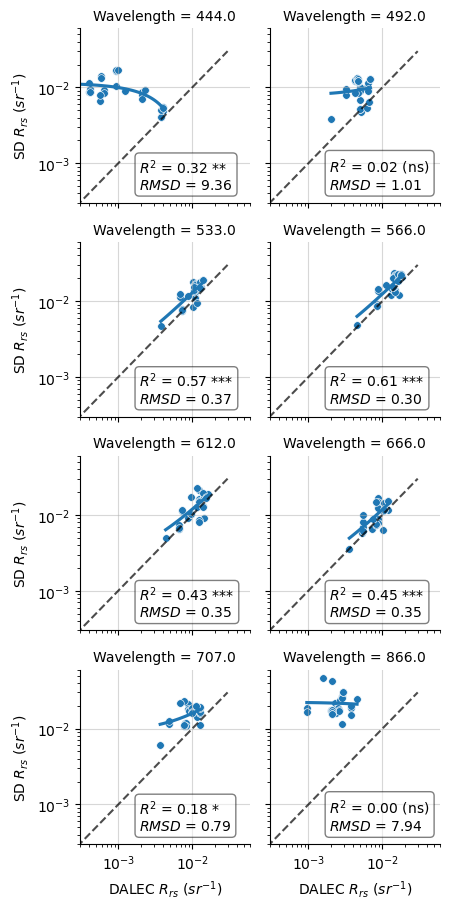

In [36]:
# g = sns.FacetGrid(dalec_sd,#[dalec_sd.year == 2023],
#                   col='Wavelength', col_wrap=2, height=2,
#                   #sharex=False, sharey=False
#                  )

def annotate(data, x='Chl-a', y='sdfkjdf', order=1, plot=True, lims=None, **kws):
    res = sp.stats.linregress(data.dropna()[x]**order, data.dropna()[y])
    mae = MAE(data.dropna()[x], data.dropna()[y])
    mape = MAPE(data.dropna()[x], data.dropna()[y])
    rmsd = RMSD(data.dropna()[x], data.dropna()[y])
    bias = SSPB(data.dropna()[x], data.dropna()[y])
    mad = MAD(data.dropna()[x], data.dropna()[y])
    mapd = MAPD(data.dropna()[x], data.dropna()[y])
    mdsa = MDSA(data.dropna()[x], data.dropna()[y])
    print('\nwavelength = ' + str(data.Wavelength.unique()))
    print('MAE: '+ str(mae))
    print('MAPE: ' + str(mape))
    print('RMSD: ' + str(rmsd))
    print('bias: ' + str(bias))
    print('MAD: ' + str(mad))
    print('MAPD: ' + str(mapd))
    print('MDSA: ' + str(mdsa))
    print('R2: ' + str(res.rvalue**2))
    print('p-val: ' + str(res.pvalue))
    psig = p_sig(res.pvalue)
    
    ax = plt.gca()
    textstr = '\n'.join((
                         r'$R^2$ = {:.2f} {}'.format(res.rvalue**2,
                                                     psig),
                         r'$RMSD$ = {:.2f}'.format(rmsd, )))
    ax.text(0.35, 0.08, textstr,
        transform=ax.transAxes, bbox=dict(boxstyle='round',
                                          facecolor='white',
                                          alpha=0.5),
            )
    
    if plot:
        ax.plot([0.1, 100], [0.1, 100], 'k--', alpha=0.6)
        
g = sns.lmplot(data=dalec_sd, col='Wavelength', col_wrap=2, height=2.3,
                x='Rrs_DALEC', y='Rrs_SD', ci=None, scatter=False)

g.map_dataframe(sns.scatterplot, x='Rrs_DALEC', y='Rrs_SD',
                #style='Sat_ID',
                #hue='year',
                legend=True,
                #style='date',
                s=30)

g.map_dataframe(annotate, x='Rrs_DALEC', y='Rrs_SD', plot=False)# lims=[0.1, 100])


for ax in g.axes.flat[:]:
    ax.plot([0, 0.03], [0, 0.03], 'k--', alpha=0.7)
    ax.set_xlim(.3e-3, 0.06)
    ax.set_ylim(.3e-3, 0.06)
    ax.grid(alpha=0.5)
    ax.set_xlabel('DALEC $R_{rs}$ ($sr^{-1}$)')
    ax.set_ylabel('SD $R_{rs}$ ($sr^{-1}$)')


g.set(xscale="log")
g.set(yscale="log")


plt.tight_layout()
#plt.gca().legend()
plt.savefig('figures_for_paper/SD_DALEC_match.svg', dpi=300)


plt.show()




In [37]:
dalec_sd.Date.unique()

<DatetimeArray>
['2022-08-10 10:27:06+00:00', '2022-08-11 10:28:21+00:00',
 '2022-08-11 10:28:23+00:00', '2022-08-13 11:13:41+00:00',
 '2022-08-17 11:03:56+00:00', '2022-08-17 11:03:58+00:00',
 '2023-07-08 10:29:51+00:00', '2023-07-12 10:31:47+00:00',
 '2023-07-12 11:05:26+00:00', '2023-07-21 10:34:37+00:00',
 '2023-07-21 10:34:40+00:00', '2023-07-21 10:35:46+00:00',
 '2023-08-26 11:06:47+00:00', '2023-08-26 11:06:49+00:00',
 '2023-08-31 11:11:37+00:00', '2023-08-31 11:11:40+00:00',
 '2023-09-01 10:25:01+00:00', '2023-09-01 10:25:03+00:00',
 '2023-09-03 10:36:33+00:00', '2023-09-07 10:30:39+00:00',
 '2023-09-07 11:11:44+00:00', '2023-09-07 11:11:46+00:00',
 '2023-09-08 11:10:06+00:00', '2023-09-08 11:10:08+00:00',
 '2023-09-11 10:30:46+00:00', '2023-09-12 10:32:01+00:00',
 '2023-09-12 11:11:16+00:00', '2023-10-01 11:10:51+00:00']
Length: 28, dtype: datetime64[ns, UTC]

In [38]:
dalec_sd

,Wavelength,date,Rrs_DALEC,Date,Rrs_SD,original_date,date_flag
10,444.0,2022-08-10,0.004061,2022-08-10 10:27:06+00:00,0.004927,nan,0.0
11,444.0,2022-08-11,0.003798,2022-08-11 10:28:21+00:00,0.004032,nan,0.0
12,444.0,2022-08-11,0.003798,2022-08-11 10:28:23+00:00,0.004113,nan,0.0
14,444.0,2022-08-13,0.003795,2022-08-13 11:13:41+00:00,0.005004,nan,0.0
16,444.0,2022-08-15,0.003999,2022-08-17 11:03:56+00:00,0.005505,2022-08-17,1.0
...,...,...,...,...,...,...,...
848,866.0,2023-09-08,0.002888,2023-09-08 11:10:08+00:00,0.030101,nan,0.0
851,866.0,2023-09-11,0.001588,2023-09-11 10:30:46+00:00,0.047072,nan,0.0
852,866.0,2023-09-12,0.000951,2023-09-12 10:32:01+00:00,0.018563,nan,0.0
853,866.0,2023-09-12,0.000951,2023-09-12 11:11:16+00:00,0.016521,nan,0.0



wavelength = [444.]
MAE: 0.007400463552248662
MAPE: 1162.3175662067113
RMSD: 9.360750785170106
bias: 1127.1898209815988
MAD: 6.636059263459751
MAPD: 1130.4243756986814
MDSA: 1127.1898209815988
R2: 0.32039385328940934
p-val: 0.0016916310002807887

wavelength = [492.]
MAE: 0.0043516304896033964
MAPE: 93.67480477366828
RMSD: 1.0119624200388952
bias: 86.44011198624158
MAD: 0.8233768649453121
MAPD: 86.44498239548984
MDSA: 86.44011198624158
R2: 0.01539963028563697
p-val: 0.529249850874237

wavelength = [533.]
MAE: 0.003276462696497716
MAPE: 32.12231387601974
RMSD: 0.3668120489194111
bias: 28.80284014368182
MAD: 0.3064923097540977
MAPD: 28.80402260761269
MDSA: 28.80284014368182
R2: 0.5721854752574647
p-val: 3.212749777055362e-06

wavelength = [566.]
MAE: 0.0034809327551775238
MAPE: 25.372724343888642
RMSD: 0.3047886428449742
bias: 14.890111685142159
MAD: 0.24442267748128144
MAPD: 18.701739231542536
MDSA: 18.65513070972904
R2: 0.6058110202012964
p-val: 1.080607755455031e-06

wavelength = [612

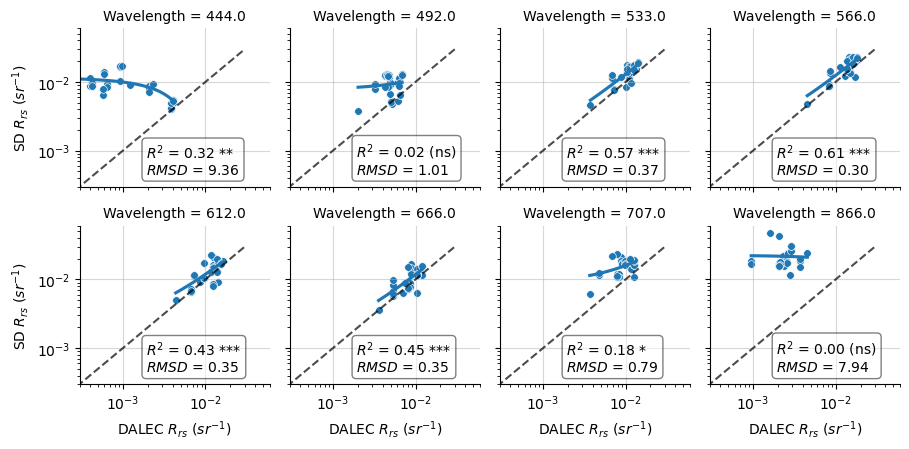

In [39]:
# g = sns.FacetGrid(dalec_sd,#[dalec_sd.year == 2023],
#                   col='Wavelength', col_wrap=2, height=2,
#                   #sharex=False, sharey=False
#                  )

def annotate(data, x='Chl-a', y='sdfkjdf', order=1, plot=True, lims=None, **kws):
    res = sp.stats.linregress(data.dropna()[x]**order, data.dropna()[y])
    mae = MAE(data.dropna()[x], data.dropna()[y])
    mape = MAPE(data.dropna()[x], data.dropna()[y])
    rmsd = RMSD(data.dropna()[x], data.dropna()[y])
    bias = SSPB(data.dropna()[x], data.dropna()[y])
    mad = MAD(data.dropna()[x], data.dropna()[y])
    mapd = MAPD(data.dropna()[x], data.dropna()[y])
    mdsa = MDSA(data.dropna()[x], data.dropna()[y])
    
    psig = p_sig(res.pvalue)
    
    print('\nwavelength = ' + str(data.Wavelength.unique()))
    print('MAE: '+ str(mae))
    print('MAPE: ' + str(mape))
    print('RMSD: ' + str(rmsd))
    print('bias: ' + str(bias))
    print('MAD: ' + str(mad))
    print('MAPD: ' + str(mapd))
    print('MDSA: ' + str(mdsa))
    print('R2: ' + str(res.rvalue**2))
    print('p-val: ' + str(res.pvalue))
    
    ax = plt.gca()
    textstr = '\n'.join((
                         r'$R^2$ = {:.2f} {}'.format(res.rvalue**2,
                                                     psig),
                         r'$RMSD$ = {:.2f}'.format(rmsd, )))
    ax.text(0.35, 0.08, textstr,
        transform=ax.transAxes, bbox=dict(boxstyle='round',
                                          facecolor='white',
                                          alpha=0.5),
            )
    
    if plot:
        ax.plot([0.1, 100], [0.1, 100], 'k--', alpha=0.6)
        
g = sns.lmplot(data=dalec_sd, col='Wavelength', col_wrap=4, height=2.3,
                x='Rrs_DALEC', y='Rrs_SD', ci=None, scatter=False)

g.map_dataframe(sns.scatterplot, x='Rrs_DALEC', y='Rrs_SD',
                #style='Sat_ID',
                #hue='year',
                legend=True,
                #style='date',
                s=30)

g.map_dataframe(annotate, x='Rrs_DALEC', y='Rrs_SD', plot=False)# lims=[0.1, 100])


for ax in g.axes.flat[:]:
    ax.plot([0, 0.03], [0, 0.03], 'k--', alpha=0.7)
    ax.set_xlim(.3e-3, 0.06)
    ax.set_ylim(.3e-3, 0.06)
    ax.grid(alpha=0.5)
    ax.set_xlabel('DALEC $R_{rs}$ ($sr^{-1}$)')
    ax.set_ylabel('SD $R_{rs}$ ($sr^{-1}$)')


g.set(xscale="log")
g.set(yscale="log")


plt.tight_layout()
#plt.gca().legend()

plt.savefig('figs_for_presentation/SD_DALEC_match.svg', dpi=300)


plt.show()




In [40]:
dalec_S2.Rrs_S2

0      0.001898
1      0.003524
2      0.016816
3      0.003478
4      0.001947
         ...   
112    0.023138
113    0.010432
114    0.068363
115    0.007871
116    0.019838
Name: Rrs_S2, Length: 117, dtype: object

In [41]:
dalec_S2.Rrs_S2 = dalec_S2.Rrs_S2.astype(float)

In [42]:
dalec_S2

,Wavelength,date,Rrs_DALEC,Date,Rrs_S2,original_date,date_flag
0,443.0,2022-07-28,0.003404,2022-07-29 11:45:40.942094+00:00,0.001898,2022-07-29,1.0
1,443.0,2023-09-01,0.000871,2023-09-02 11:45:40.778585+00:00,0.003524,2023-09-02,1.0
2,443.0,2023-09-12,0.000529,2023-09-12 11:45:39.402233+00:00,0.016816,nan,0.0
3,443.0,2023-09-29,0.000183,2023-09-29 11:35:41.859230+00:00,0.003478,nan,0.0
4,492.0,2022-07-28,0.004902,2022-07-29 11:45:40.942094+00:00,0.001947,2022-07-29,1.0
...,...,...,...,...,...,...,...
112,865.0,2023-07-29,0.007271,2023-07-29 11:45:41.220752+00:00,0.023138,nan,0.0
113,865.0,2023-08-08,0.001983,2023-08-08 11:45:40.340448+00:00,0.010432,nan,0.0
114,865.0,2023-08-28,0.002710,2023-08-28 11:45:41.668952+00:00,0.068363,nan,0.0
115,865.0,2023-09-06,0.002989,2023-09-04 11:35:44.833521+00:00,0.007871,2023-09-04,1.0


In [43]:
dalec_S2.date.unique()

<DatetimeArray>
['2022-07-28 00:00:00', '2023-09-01 00:00:00', '2023-09-12 00:00:00',
 '2023-09-29 00:00:00', '2022-08-10 00:00:00', '2023-07-09 00:00:00',
 '2023-07-16 00:00:00', '2023-07-19 00:00:00', '2023-07-29 00:00:00',
 '2023-08-08 00:00:00', '2023-08-28 00:00:00', '2023-09-06 00:00:00',
 '2023-09-07 00:00:00']
Length: 13, dtype: datetime64[ns]


wavelength = [443.]
MAE: 0.013619269732538295
MAPE: 2631.2892005426647
RMSD: 19.44995483221403
bias: 2575.851088794736
MAD: 13.74144904115942
MAPD: 2575.8510887947355
MDSA: 2575.851088794736
R2: 0.04000456946605442
p-val: 0.5123652070388701

wavelength = [492.]
MAE: 0.010701012728250189
MAPE: 214.74822603622425
RMSD: 2.274425848599037
bias: 81.93081717289282
MAD: 1.663941349361004
MAPD: 81.9308171728928
MDSA: 163.69979236703136
R2: 0.05352442844955313
p-val: 0.44694667554434553

wavelength = [560.]
MAE: 0.010660803223072819
MAPE: 82.17134306695387
RMSD: 0.955347525653738
bias: 43.10512462155418
MAD: 0.7449596260745213
MAPD: 55.804286810361084
MDSA: 64.33835710086511
R2: 0.33702114103609354
p-val: 0.03750167315958156

wavelength = [665.]
MAE: 0.008234186636910836
MAPE: 97.95544391646533
RMSD: 1.2824383157557233
bias: 27.682481451565664
MAD: 0.8609960305673441
MAPD: 40.19546954363878
MDSA: 57.85954091546319
R2: 0.20265014352868044
p-val: 0.12268881937085115

wavelength = [704.]
MAE: 0.0

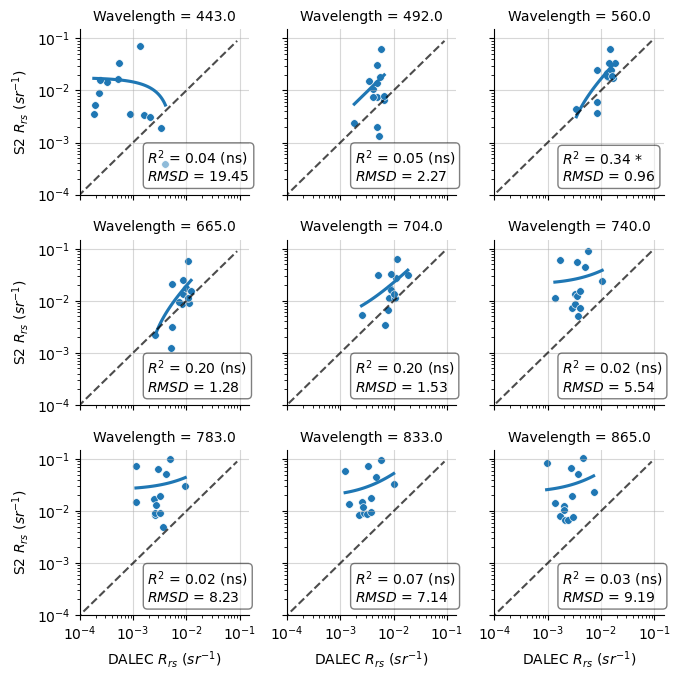

In [44]:
# g = sns.FacetGrid(dalec_S2,#[dalec_sd.year == 2023],
#                   col='Wavelength', col_wrap=3, height=2)

def annotate(data, x='Chl-a', y='sdfkjdf', order=1, plot=True, lims=None, **kws):
    res = sp.stats.linregress(data.dropna()[x]**order, data.dropna()[y])
    mae = MAE(data.dropna()[x], data.dropna()[y])
    mape = MAPE(data.dropna()[x], data.dropna()[y])
    rmsd = RMSD(data.dropna()[x], data.dropna()[y])
    bias = SSPB(data.dropna()[x], data.dropna()[y])
    mad = MAD(data.dropna()[x], data.dropna()[y])
    mapd = MAPD(data.dropna()[x], data.dropna()[y])
    mdsa = MDSA(data.dropna()[x], data.dropna()[y])
    
    psig = p_sig(res.pvalue)
    
    print('\nwavelength = ' + str(data.Wavelength.unique()))
    print('MAE: '+ str(mae))
    print('MAPE: ' + str(mape))
    print('RMSD: ' + str(rmsd))
    print('bias: ' + str(bias))
    print('MAD: ' + str(mad))
    print('MAPD: ' + str(mapd))
    print('MDSA: ' + str(mdsa))
    print('R2: ' + str(res.rvalue**2))
    print('p-val: ' + str(res.pvalue))
    
    ax = plt.gca()
    textstr = '\n'.join((
                         r'$R^2$ = {:.2f} {}'.format(res.rvalue**2,
                                                     psig),
                         r'$RMSD$ = {:.2f}'.format(rmsd, )))
    ax.text(0.4, 0.08, textstr,
        transform=ax.transAxes, bbox=dict(boxstyle='round',
                                          facecolor='white',
                                          alpha=0.5),
            )
    
    if plot:
        ax.plot([0.1, 100], [0.1, 100], 'k--', alpha=0.6)




g = sns.lmplot(data=dalec_S2, col='Wavelength', col_wrap=3, height=2.3,
                x='Rrs_DALEC', y='Rrs_S2', ci=None, scatter=False)

g.map_dataframe(sns.scatterplot, x='Rrs_DALEC', y='Rrs_S2',
                #style='Sat_ID',
                #hue='year',
                legend=True,
                #style='date',
                s=30)

g.map_dataframe(annotate, x='Rrs_DALEC', y='Rrs_S2', plot=False)# lims=[0.1, 100])


for ax in g.axes.flat:
    ax.plot([0, 0.09], [0, 0.09], 'k--', alpha=0.7)
    ax.set_xlim(1e-4, 0.15)
    ax.set_ylim(1e-4, 0.15)
    ax.grid(alpha=0.5)
    ax.set_xlabel('DALEC $R_{rs}$ ($sr^{-1}$)')
    ax.set_ylabel('S2 $R_{rs}$ ($sr^{-1}$)')
    
g.set(xscale="log")
g.set(yscale="log")

plt.tight_layout()
#plt.gca().legend()

plt.savefig('figs_for_presentation/S2_DALEC_match.pdf', dpi=300)
plt.savefig('figures_for_paper/S2_DALEC_match.svg', dpi=300)



plt.show()




In [45]:
def chla_NIR_rat(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666'):
    '''
    just use NIR ratio 708/666 with no coefficients
    '''
    ratio = df[Rrs_708] / df[Rrs_666]
    return ratio

def chla_NIR_rat_org(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666',
                     a=61.324, b=-37.94):
    return a * chla_NIR_rat(df, Rrs_708=Rrs_708, Rrs_666=Rrs_666) + b

def chla_NDCI(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666'):
    '''
    use NCDI NIR ratio (708-666)/(708+666)
    '''
    ratio = (df[Rrs_708] - df[Rrs_666]) / (df[Rrs_708] + df[Rrs_666])
    return ratio

def chla_NDCI_org(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666',
                  a=42.197, b=236.5, c=314.97):
    ratio = chla_NDCI(df, Rrs_708=Rrs_708, Rrs_666=Rrs_666)
    return a + (b*ratio) + (c*ratio**2)


def chla_OC4(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.3255, b=-2.7677,
             c=2.4409, d=-1.1288, e=-0.4990, returnX=False):
    '''4 band NASA alg (model L in claire neil paper)'''
    X = np.log10(np.array(np.max([df[Rrs_444], df[Rrs_492], df[Rrs_533]], axis=0)/df[Rrs_566], dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))

def chla_OC4_mod(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.3255, b=-2.7677,
             c=2.4409, d=-1.1288, e=-0.4990, returnX=False):
    '''4 band NASA alg (model L in claire neil paper)
    with Rrs_444 removed as we cant trust this one... '''
    X = np.log10(np.array(np.max([df[Rrs_492], df[Rrs_533]], axis=0)/df[Rrs_566], dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))
    
def chla_OC3(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.2424, b=-2.2146,
             c=1.5193, d=-0.7702,
             e=-0.4291, returnX=False):
    '''3 band NASA alg (model M in claire neil paper)'''
    X = np.log10(np.array(np.max([df[Rrs_444],
                                  df[Rrs_492]],
                                 axis=0)/(df[Rrs_566]), dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))
                
def chla_OC2(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.2389, b=-1.9369,
             c=1.7627, d=-3.0777,
             e=-0.1054, returnX=False):
    '''2 band NASA alg (model N in claire neil paper)'''
    X = np.log10(np.array(df[Rrs_492]/df[Rrs_566], dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))
    
def chla_RBD(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666'):
    '''
    NIR/red band difference
    '''
    return df[Rrs_708] - df[Rrs_666]

def chla_RBR3(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666', Rrs_866='Rrs_866'):
    return (df[Rrs_666]**-1 - df[Rrs_708]**-1) * df[Rrs_866]

def chla_RBR3_org(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666', Rrs_866='Rrs_866',
                  a=-0.0620/0.016, b=0.1166/0.016
                 ):
    '''
    coefficients from quintin's paper 
    '''
    RBR3 = (df[Rrs_666]**-1 - df[Rrs_708]**-1) * df[Rrs_866]
    return a + RBR3*b

def chla_RBD_org(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666',
                 #a=-0.0134/0.016, b=0.0258/0.016
                a=1.8, b=27580):
    '''
    NIR/red band difference with coeffs from 
    https://www.sciencedirect.com/science/article/pii/S0034425719302470?via%3Dihub
    
    '''
    rbd = df[Rrs_708] - df[Rrs_666]
    return a + b*rbd


In [46]:
0.1166/0.016

7.2875

In [47]:
S2_med.Wavelength.unique()

array([ 442.,  492.,  559.,  665.,  704.,  739.,  780.,  833.,  864.,
       1610., 2186.,  443.,  560.,  740.,  783.,  865., 1614., 2202.])

In [48]:
SD_med

,Date,date,Wavelength,Rrs_SD,original_date,date_flag
0,2020-04-07 10:35:46+00:00,2020-04-07,444.0,0.006075,nan,0
1,2020-04-07 10:35:46+00:00,2020-04-07,492.0,0.006498,nan,0
2,2020-04-07 10:35:46+00:00,2020-04-07,533.0,0.007883,nan,0
3,2020-04-07 10:35:46+00:00,2020-04-07,566.0,0.007561,nan,0
4,2020-04-07 10:35:46+00:00,2020-04-07,612.0,0.007404,nan,0
...,...,...,...,...,...,...
2667,2024-04-08 11:33:14+00:00,2024-04-08,566.0,0.007957,nan,0
2668,2024-04-08 11:33:14+00:00,2024-04-08,612.0,0.007067,nan,0
2669,2024-04-08 11:33:14+00:00,2024-04-08,666.0,0.007612,nan,0
2670,2024-04-08 11:33:14+00:00,2024-04-08,707.0,0.012807,nan,0


In [49]:
S2_med_ab = S2_med.copy()[S2_med.Wavelength<866]
# set s2a and s2b wavelengths to be the same
S2_med_ab['Wavelength'] = S2_med_ab.Wavelength.apply(nearest_wavelength,
                                                   args=[dalec_s2a.Wavelength.unique()])

s2_dict = {'Date':S2_med_ab[S2_med_ab.Wavelength==443.0].reset_index().Date,
           'date':S2_med_ab[S2_med_ab.Wavelength==443.0].reset_index().date}
sd_dict = {'Date':SD_med[SD_med.Wavelength==444.0].reset_index().Date,
           'date':SD_med[SD_med.Wavelength==444.0].reset_index().date}
dalec_dict = {'date':dalec_S2A[dalec_S2A.Wavelength==443.0].reset_index().date}

for wavelength in S2_med_ab.Wavelength.unique():
    s2_dict['Rrs_'+str(int(wavelength))] = S2_med_ab[S2_med_ab.Wavelength==wavelength].reset_index().Rrs_S2
    dalec_dict['Rrs_'+str(int(wavelength))] = dalec_S2A[dalec_S2A.Wavelength==wavelength].reset_index().Rrs_DALEC

for wavelength in SD_med.Wavelength.unique():
    sd_dict['Rrs_'+str(int(wavelength))] = SD_med[SD_med.Wavelength==wavelength].reset_index().Rrs_SD

    
s2_chla = pd.DataFrame(data=s2_dict)
sd_chla = pd.DataFrame(data=sd_dict)
dalec_chla = pd.DataFrame(data=dalec_dict)

In [50]:
sd_chla = sd_chla.groupby('date').median().reset_index()

In [51]:
# sentinel 2

s2_chla['NIR'] = chla_NIR_rat(s2_chla, Rrs_708='Rrs_704', Rrs_666='Rrs_665')
s2_chla['NDCI'] = chla_NDCI(s2_chla, Rrs_708='Rrs_704', Rrs_666='Rrs_665')
s2_chla['RBD'] = chla_RBD(s2_chla, Rrs_708='Rrs_704', Rrs_666='Rrs_665')
s2_chla['RBR3'] = chla_RBR3(s2_chla, Rrs_708='Rrs_704',
                            Rrs_666='Rrs_665', Rrs_866='Rrs_865')

s2_chla['NIR_org'] = chla_NIR_rat_org(s2_chla, Rrs_708='Rrs_704', Rrs_666='Rrs_665')
s2_chla['NDCI_org'] = chla_NDCI_org(s2_chla, Rrs_708='Rrs_704', Rrs_666='Rrs_665')
s2_chla['RBD_org'] = chla_RBD_org(s2_chla, Rrs_708='Rrs_704', Rrs_666='Rrs_665')
s2_chla['RBR3_org'] = chla_RBR3_org(s2_chla, Rrs_708='Rrs_704',
                            Rrs_666='Rrs_665', Rrs_866='Rrs_865')


s2_chla['OC3_X'] = chla_OC3(s2_chla, returnX=True,
                            Rrs_444='Rrs_443', Rrs_492='Rrs_492',
                            Rrs_566='Rrs_560',)
s2_chla['OC2_X'] = chla_OC2(s2_chla, returnX=True,
                            Rrs_444='Rrs_443', Rrs_492='Rrs_492',
                            Rrs_566='Rrs_560',)


s2_chla['OC3'] = chla_OC3(s2_chla,
                          Rrs_444='Rrs_443', Rrs_492='Rrs_492',
                          Rrs_566='Rrs_560',)
s2_chla['OC2'] = chla_OC2(s2_chla,
                          Rrs_444='Rrs_443', Rrs_492='Rrs_492',
                          Rrs_566='Rrs_560',)

# dalec

dalec_chla['NIR'] = chla_NIR_rat(dalec_chla, Rrs_708='Rrs_704', Rrs_666='Rrs_665')
dalec_chla['NDCI'] = chla_NDCI(dalec_chla, Rrs_708='Rrs_704', Rrs_666='Rrs_665')
dalec_chla['RBD'] = chla_RBD(dalec_chla, Rrs_708='Rrs_704', Rrs_666='Rrs_665')
dalec_chla['RBR3'] = chla_RBR3(dalec_chla, Rrs_708='Rrs_704',
                               Rrs_666='Rrs_665', Rrs_866='Rrs_865')

dalec_chla['NIR_org'] = chla_NIR_rat_org(dalec_chla, Rrs_708='Rrs_704', Rrs_666='Rrs_665')
dalec_chla['NDCI_org'] = chla_NDCI_org(dalec_chla, Rrs_708='Rrs_704', Rrs_666='Rrs_665')
dalec_chla['RBD_org'] = chla_RBD_org(dalec_chla, Rrs_708='Rrs_704', Rrs_666='Rrs_665')
dalec_chla['RBR3_org'] = chla_RBR3_org(dalec_chla, Rrs_708='Rrs_704',
                               Rrs_666='Rrs_665', Rrs_866='Rrs_865')

dalec_chla['OC3_X'] = chla_OC3(dalec_chla, returnX=True,
                               Rrs_444='Rrs_443', Rrs_492='Rrs_492',
                               Rrs_566='Rrs_560',)
dalec_chla['OC2_X'] = chla_OC2(dalec_chla, returnX=True, 
                               Rrs_444='Rrs_443', Rrs_492='Rrs_492',
                               Rrs_566='Rrs_560',)

dalec_chla['OC3'] = chla_OC3(dalec_chla, Rrs_444='Rrs_443',
                             Rrs_492='Rrs_492',
                             Rrs_566='Rrs_560',)
dalec_chla['OC2'] = chla_OC2(dalec_chla, Rrs_444='Rrs_443',
                             Rrs_492='Rrs_492',
                             Rrs_566='Rrs_560',)


In [52]:
sd_chla['NIR'] = chla_NIR_rat(sd_chla)
sd_chla['NDCI'] = chla_NDCI(sd_chla)
sd_chla['RBD'] = chla_RBD(sd_chla)
sd_chla['RBR3'] = chla_RBR3(sd_chla)

sd_chla['NIR_org'] = chla_NIR_rat_org(sd_chla)
sd_chla['NDCI_org'] = chla_NDCI_org(sd_chla)
sd_chla['RBD_org'] = chla_RBD_org(sd_chla)
sd_chla['RBR3_org'] = chla_RBR3_org(sd_chla)

sd_chla['OC4_X'] = chla_OC4(sd_chla, returnX=True)
sd_chla['OC4_mod_X'] = chla_OC4_mod(sd_chla, returnX=True)

sd_chla['OC3_X'] = chla_OC3(sd_chla, returnX=True)
sd_chla['OC2_X'] = chla_OC2(sd_chla, returnX=True)

sd_chla['OC4'] = chla_OC4(sd_chla)
sd_chla['OC3'] = chla_OC3(sd_chla)
sd_chla['OC2'] = chla_OC2(sd_chla)


In [53]:
insitu_chl = pd.read_csv('data/chl-a/airthrey_chl.csv')
insitu_chl.Date = pd.to_datetime(insitu_chl.Date, dayfirst=True)

In [54]:
# not my finest work, but does the job
# by the way, the job being that we are finding the closest in-situ measurements to the S2 data! 


for alg in ['OC3_X', 'OC2_X',
            'OC3', 'OC2', 'NIR', 'NDCI', 'RBD', 'RBR3',
            'NIR_org', 'NDCI_org', 'RBD_org', 'RBR3_org']:
    selected_dates = []
    date_diffs = []
    selected_chl = []
    for s2_date in insitu_chl.Date:
        date_deltas = []
        for ins_date in s2_chla.date:
            #print(ins_date)
            date_deltas.append(s2_date - ins_date)
        date_deltas = np.array(np.abs(date_deltas))
        min_ind = np.where(date_deltas==date_deltas.min())
        #print(min_ind)
        selected_dates.append(s2_chla.date[min_ind[0][0]])
        date_diffs.append(date_deltas[min_ind[0][0]])
        selected_chl.append(s2_chla[alg][min_ind[0][0]])
    

    insitu_chl[alg] =  selected_chl
    insitu_chl['sat_date'] = selected_dates
    insitu_chl['date_diff'] = date_diffs

In [55]:
insit_reduced_S2 = insitu_chl.loc[insitu_chl.groupby('sat_date').date_diff.idxmin()]
insit_reduced_S2 = insit_reduced_S2[insit_reduced_S2.date_diff<'5d']
insit_reduced_S2 #= sd_reduced[sd_reduced.date.dt.year==2023]
insit_reduced_S2['year'] = insit_reduced_S2.Date.dt.year

In [56]:
# not my finest work, but does the job
# by the way, the job being that we are finding the closest in-situ measurements to the superdoves data! 


for alg in ['OC4_X', 'OC4_mod_X', 'OC3_X', 'OC2_X', 'OC4',
            'OC3', 'OC2', 'NIR', 'NDCI', 'RBD', 'RBR3',
            'NIR_org', 'NDCI_org', 'RBD_org', 'RBR3_org']:
    selected_dates = []
    date_diffs = []
    selected_chl = []
    for sd_date in insitu_chl.Date:
        date_deltas = []
        for ins_date in sd_chla.date:
            #print(ins_date)
            date_deltas.append(sd_date - ins_date)
        date_deltas = np.array(np.abs(date_deltas))
        min_ind = np.where(date_deltas==date_deltas.min())
        #print(min_ind)
        selected_dates.append(sd_chla.date[min_ind[0][0]])
        date_diffs.append(date_deltas[min_ind[0][0]])
        selected_chl.append(sd_chla[alg][min_ind[0][0]])
    

    insitu_chl[alg] =  selected_chl
    insitu_chl['sat_date'] = selected_dates
    insitu_chl['date_diff'] = date_diffs

In [57]:
insitu_chl

,Date,Chl-a,OC3_X,sat_date,date_diff,OC2_X,OC3,OC2,NIR,NDCI,RBD,RBR3,NIR_org,NDCI_org,RBD_org,RBR3_org,OC4_X,OC4_mod_X,OC4
0,2022-07-05,2.663,-0.158048,2022-07-04,1 days,-0.323260,4.296707,14.191643,2.043316,0.342822,0.005705,2.178559,87.364337,160.291948,159.132576,12.001248,-0.158048,-0.181068,6.730458
1,2022-07-07,2.592,-0.070437,2022-07-07,0 days,-0.249384,2.547929,7.566301,2.399782,0.411727,0.004720,3.212032,109.224261,192.963908,131.990888,19.532681,-0.066217,-0.066217,3.309698
2,2022-07-20,6.163,-0.215524,2022-07-10,10 days,-0.215524,6.266944,5.872326,2.002922,0.333982,0.004513,2.307454,84.887178,156.316747,126.257062,12.940572,-0.072081,-0.072081,3.452151
3,2022-07-27,5.465,-0.273982,2022-08-10,14 days,-0.292907,9.476118,10.815028,1.926368,0.316559,0.005270,1.343688,80.192569,148.626165,147.133644,5.917124,-0.090404,-0.090404,3.948760
4,2022-08-04,8.361,-0.273982,2022-08-10,6 days,-0.292907,9.476118,10.815028,1.926368,0.316559,0.005270,1.343688,80.192569,148.626165,147.133644,5.917124,-0.090404,-0.090404,3.948760
5,2022-08-19,37.789,-0.327097,2022-08-20,1 days,-0.327097,14.170480,14.707961,2.311943,0.396125,0.010631,1.556804,103.837604,185.304040,294.997809,7.470208,-0.100764,-0.100764,4.268469
6,2022-08-25,89.650,-0.294393,2022-08-27,2 days,-0.422817,11.027165,40.017341,2.043362,0.342832,0.015544,1.567751,87.367125,160.296391,430.506605,7.549986,-0.107714,-0.107714,4.500733
7,2022-09-01,78.244,-0.294393,2022-08-27,5 days,-0.422817,11.027165,40.017341,2.043362,0.342832,0.015544,1.567751,87.367125,160.296391,430.506605,7.549986,-0.107714,-0.107714,4.500733
8,2022-09-09,16.429,-0.104001,2022-09-10,1 days,-0.255113,3.090075,7.914125,1.510896,0.203472,0.003889,0.741744,54.714209,103.358048,109.060631,1.530460,-0.091874,-0.091874,3.992304
9,2022-09-12,21.707,-0.226969,2022-09-12,0 days,-0.323704,6.779195,14.250257,1.707078,0.261196,0.004326,0.813081,66.744831,125.458135,121.098144,2.050326,-0.110485,-0.110485,4.597623


In [58]:
insit_reduced_SD = insitu_chl.loc[insitu_chl.groupby('sat_date').date_diff.idxmin()]
insit_reduced_SD = insit_reduced_SD[insit_reduced_SD.date_diff<'100d']
insit_reduced_SD #= sd_reduced[sd_reduced.date.dt.year==2023]
insit_reduced_SD['year'] = insit_reduced_SD.Date.dt.year

In [59]:
def RBI_polyfit(df, alg, chla_name='Chl-a', debug=False, returnCoeff=False):
    '''
    fits a linear model to the data in df[alg] against df[chla_name] 
    '''
    coeff = np.polyfit(df[alg],
                       df[chla_name], deg=1)
    if debug:
        print(coeff)
        print(df[alg])
        print(df[chla_name])
    if returnCoeff:
        return coeff
    else:
        return np.polyval(coeff, df[alg])
    
def OC_polyfit(df, alg, chla_name='Chl-a', debug=False, returnCoeff=False):
    '''
    fits a 4th order polynomial to the data in df[alg] against df[chla_name]\
    alg should be the X output from one of the OC algorithms
    uses log10 of chl-a to match 
    '''
    coeff = np.polyfit(df[alg],
                       np.log10(df[chla_name]), deg=4)
    if debug:
        print(coeff)
        print(df[alg])
        print(df[chla_name])
    if returnCoeff:
        return coeff
    else:
        return 10**(np.polyval(coeff, df[alg]))

In [60]:
for OC in ['OC2_X', 'OC3_X']:
    insit_reduced_S2[OC[:-2] + '_tuned'] = OC_polyfit(insit_reduced_S2, OC)
    print(OC)
    print('SD_coeff: ')
    OC_coeff_SD = OC_polyfit(insit_reduced_SD, OC, returnCoeff=True)
    print(OC_coeff_SD)
    sd_chla[OC[:-2] + '_tuned'] = 10**(np.polyval(OC_coeff_SD, sd_chla[OC]))
    print('S2_coeff:')
    OC_coeff_S2 = OC_polyfit(insit_reduced_S2, OC, returnCoeff=True)
    print(OC_coeff_S2)
    s2_chla[OC[:-2] + '_tuned'] = 10**(np.polyval(OC_coeff_S2, s2_chla[OC]))
    
    insit_reduced_SD[OC[:-2] + '_tuned'] = OC_polyfit(insit_reduced_SD, OC)
    
insit_reduced_SD['OC4_tuned'] = OC_polyfit(insit_reduced_SD, 'OC4_X')
print('OC4_X')
print('SD_coeff:')
OC_coeff_SD = OC_polyfit(insit_reduced_SD, 'OC4_X', returnCoeff=True)
print(OC_coeff_SD)
sd_chla['OC4_tuned'] = 10**(np.polyval(OC_coeff_SD, sd_chla['OC4_X']))

OC2_X
SD_coeff: 
[506.06892637 392.15536774  94.24865753   5.08547344   0.66076503]
S2_coeff:
[-236.21822107 -223.27846193  -60.43881125   -5.14908542    0.85427622]
OC3_X
SD_coeff: 
[-46.25366116 -12.96638103   7.29677618  -0.97394641   0.65452869]
S2_coeff:
[-46.52945764 -23.12084579   3.57432539   0.61589994   0.83770047]
OC4_X
SD_coeff:
[-1.14494220e+03  1.42784407e+02  4.78583476e+01 -4.49757978e+00
  6.59589727e-01]


In [61]:
OC_coeff_SD

array([-1.14494220e+03,  1.42784407e+02,  4.78583476e+01, -4.49757978e+00,
        6.59589727e-01])

In [62]:
for alg in ['NIR', 'NDCI', 'RBD', 'RBR3']:
    print(alg)
    insit_reduced_S2[alg + '_tuned'] = RBI_polyfit(insit_reduced_S2, alg)
    insit_reduced_SD[alg + '_tuned'] = RBI_polyfit(insit_reduced_SD, alg)
    print('SD_coeff:')
    coeff_SD = RBI_polyfit(insit_reduced_SD, alg, returnCoeff=True)
    print(coeff_SD)

    sd_chla[alg + '_tuned'] = np.polyval(coeff_SD, sd_chla[alg])
    print('S2_coeff:')
    coeff_S2 = RBI_polyfit(insit_reduced_S2, alg, returnCoeff=True)
    print(coeff_S2)
    s2_chla[alg + '_tuned'] = np.polyval(coeff_S2, s2_chla[alg])

NIR
SD_coeff:
[-2.30073398 25.10614164]
S2_coeff:
[-14.93664794  49.26958544]
NDCI
SD_coeff:
[ 0.26646029 21.06133001]
S2_coeff:
[-54.6739819   37.10374135]
RBD
SD_coeff:
[ 4.63636160e+03 -1.71869443e+00]
S2_coeff:
[4.71412516e+03 1.59045623e+00]
RBR3
SD_coeff:
[-7.79286034 31.40022337]
S2_coeff:
[-8.62183986 35.73590117]


In [63]:
insit_melt_S2 = insit_reduced_S2.melt(value_vars=['OC3', 'OC3_tuned',
                                                  'OC2', 'OC2_tuned',
                                                    'NIR', 'NDCI', 'RBD', 'RBR3',
                                                    'NIR_tuned', 'NDCI_tuned',
                                                    'RBD_tuned', 'RBR3_tuned',
                                                  'NIR_org', 'NDCI_org', 'RBD_org', 'RBR3_org'],
                                id_vars=['Date',
                                          'Chl-a',
                                          'sat_date',
                                          'date_diff'],
                                value_name='Satellite_chla',
                                var_name='Algorithm')
insit_melt_S2['Sensor'] = 'S2'


In [64]:
insit_melt_SD = insit_reduced_SD.melt(value_vars=['OC4', 'OC4_tuned',
                                                  'OC3', 'OC3_tuned',
                                                  'OC2', 'OC2_tuned',
                                                    'NIR', 'NDCI', 'RBD', 'RBR3',
                                                    'NIR_tuned', 'NDCI_tuned',
                                                    'RBD_tuned', 'RBR3_tuned',
                                                  'NIR_org', 'NDCI_org', 'RBD_org', 'RBR3_org'],
                                id_vars=['Date',
                                          'Chl-a',
                                          'sat_date',
                                          'date_diff'],
                                value_name='Satellite_chla',
                                var_name='Algorithm')
insit_melt_SD['Sensor'] = 'SD'

In [65]:
insit_melt = pd.concat([insit_melt_SD, insit_melt_S2])

In [66]:
insit_melt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 718 entries, 0 to 303
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   Date            718 non-null    datetime64[ns] 
 1   Chl-a           718 non-null    float64        
 2   sat_date        718 non-null    datetime64[ns] 
 3   date_diff       718 non-null    timedelta64[ns]
 4   Algorithm       718 non-null    object         
 5   Satellite_chla  718 non-null    float64        
 6   Sensor          718 non-null    object         
dtypes: datetime64[ns](2), float64(2), object(2), timedelta64[ns](1)
memory usage: 44.9+ KB


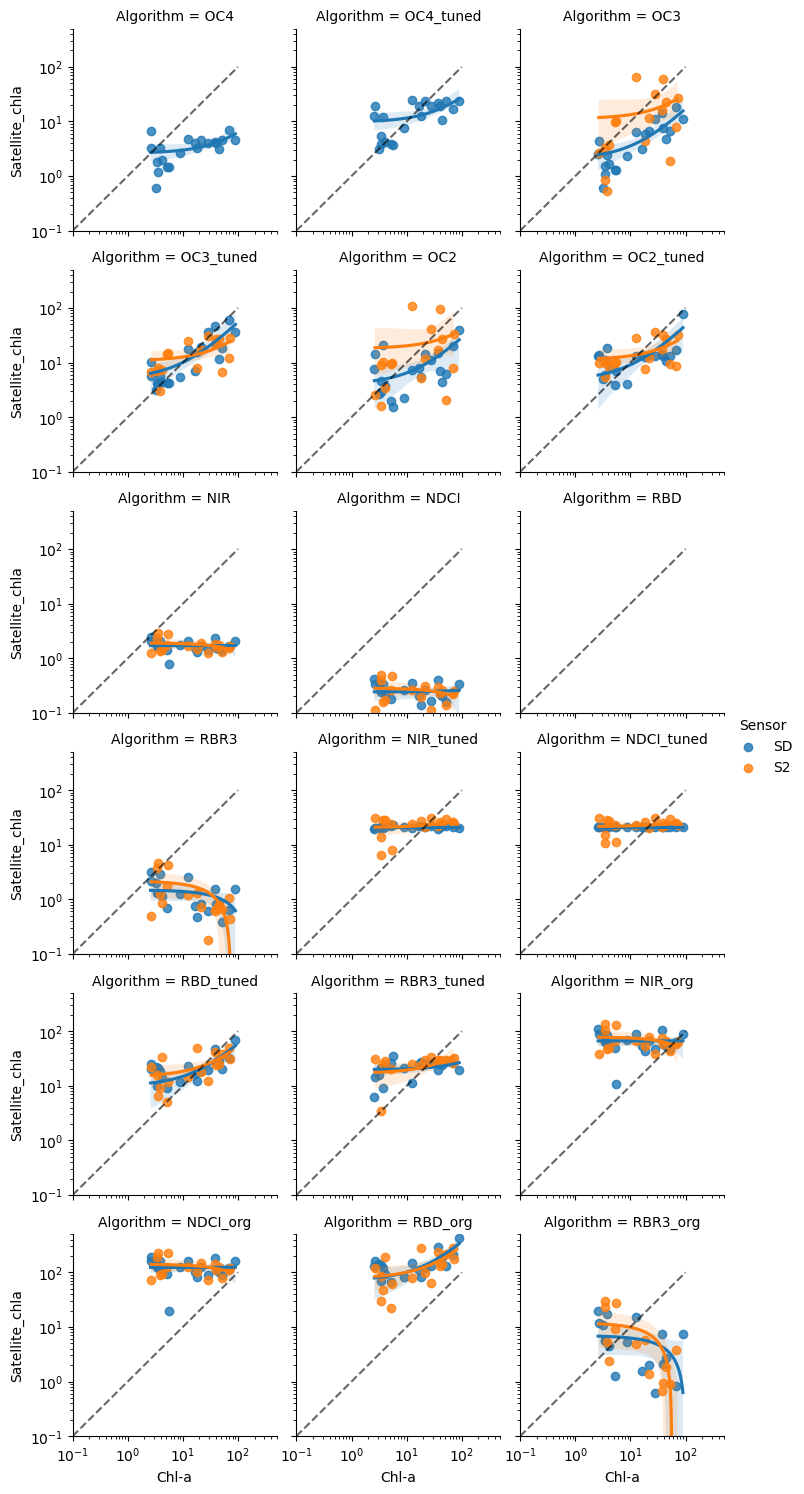

In [67]:
def annotate(data, x='Chl-a', y='sdfkjdf', order=1, plot=True, lims=None, **kws):
#     res = sp.stats.linregress(data.dropna()[x]**order, data.dropna()[y])
#     mae = MAE(data.dropna()[x], data.dropna()[y])
#     mape = MAPE(data.dropna()[x], data.dropna()[y])
#     rmsd = RMSD(data.dropna()[x], data.dropna()[y])
#     bias = SSPB(data.dropna()[x], data.dropna()[y])
#     mad = MAD(data.dropna()[x], data.dropna()[y])
#     mapd = MAPD(data.dropna()[x], data.dropna()[y])
#     ax = plt.gca()
#     ax.text(0.1, 0.77, '$R^2$ = {:.2f} \np = {:.2g}\
#                        \nRMSD = {:.2f} \nMAPD = {:.2f}%\
#                        \nMAD = {:.2f} \nBias = {:.2f}%'.format(res.rvalue**2,
#                                                               res.pvalue,
#                                                               rmsd, mapd,
#                                                               mad, bias),
#             transform=ax.transAxes)

    if plot:
        ax.plot([0.1, 100], [0.1, 100], 'k--', alpha=0.6)

g = sns.lmplot(data=insit_melt[insit_melt.date_diff <= '3 days'],
               x='Chl-a', y='Satellite_chla', col='Algorithm', hue='Sensor',
               col_wrap=3,
               facet_kws={'sharey':True, 'sharex':True}, height=2.5)
# g = sns.relplot(data=insit_melt[insit_melt.date_diff <= '3 days'],
#                 x='Chl-a', y='Satellite_chla', col='Algorithm', hue='Sensor',
#                col_wrap=3, kind='scatter',
#                facet_kws={'sharey':True, 'sharex':True}, height=2.3)
# g.map_dataframe(annotate, y='Satellite_chla', plot=True)# lims=[0.1, 100])

# lims=[[0.1, 100], [0.1, 100], [0.1, 100],
#       [.1, 100], [.1, 100], [.1, 100],
#       [0.1, 100], [0.1, 100]]

for ax in g.axes:
    ax.set_xlim(1e-1, 5e2)
    ax.set_ylim(1e-1, 5e2)
    ax.plot([0.1, 100], [0.1, 100], 'k--', alpha=0.6)
    ax.set_yscale('log')
    ax.set_xscale('log')
    
plt.show()

## Need to work out how to do the plotting in a nice way!

- think I should divide into a few seperate groups

I have:

OC2, OC3, NIR, NDCI, RBD, RBR3
(6 algorithms)

S2, SD
(2 sensors)

tuned/not tuned (2 tuning options)

BUT actually most algorithms are meaningless without coefficient

only OC2 and OC3 have generalised coeffs




In [68]:
not_tuned = insit_melt.Algorithm.isin(['NIR', 'NDCI', 'RBD', 'RBR3', 'OC4', 'OC4_tuned'])

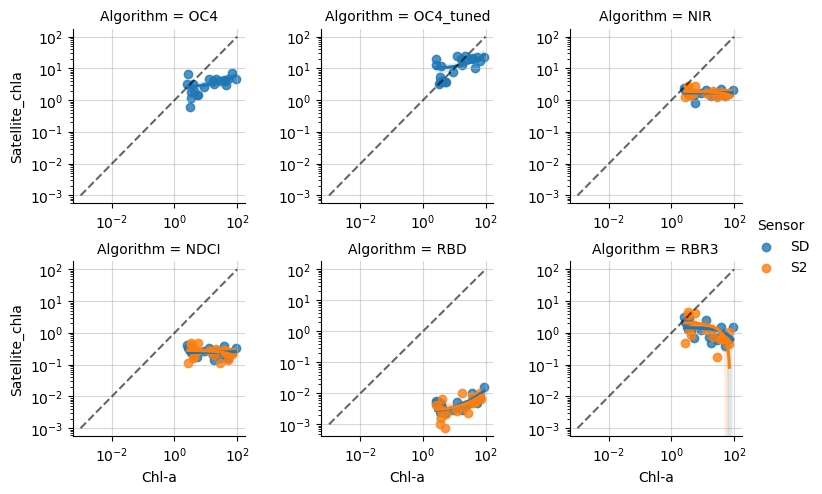

In [69]:

g = sns.lmplot(data=insit_melt[(insit_melt.date_diff <= '3 days')& not_tuned],
               x='Chl-a', y='Satellite_chla', col='Algorithm', hue='Sensor',
               col_wrap=3,
               facet_kws={'sharey':False, 'sharex':False}, height=2.5)

for ax in g.axes:
#     ax.set_xlim(1e-3, 1.2e2)
#     ax.set_ylim(1e-3, 1.2e2)
    ax.plot([1e-3, 100], [1e-3, 100], 'k--', alpha=0.6)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.grid(alpha=0.5)
    
plt.show()

In [70]:
insit_melt['year'] = insit_melt.Date.dt.year

In [71]:
insit_melt[(insit_melt.year==2022)&(insit_melt.Algorithm=='OC3_tuned')]#&(insit_melt.date_diff<='3 days')]

,Date,Chl-a,sat_date,date_diff,Algorithm,Satellite_chla,Sensor,year
69,2022-07-05,2.663,2022-07-04,1 days,OC3_tuned,10.305156,SD,2022
70,2022-07-07,2.592,2022-07-07,0 days,OC3_tuned,5.790637,SD,2022
71,2022-07-20,6.163,2022-07-10,10 days,OC3_tuned,17.115347,SD,2022
72,2022-08-04,8.361,2022-08-10,6 days,OC3_tuned,29.864355,SD,2022
73,2022-08-19,37.789,2022-08-20,1 days,OC3_tuned,47.654377,SD,2022
74,2022-08-25,89.650,2022-08-27,2 days,OC3_tuned,36.061926,SD,2022
75,2022-09-09,16.429,2022-09-10,1 days,OC3_tuned,6.980994,SD,2022
76,2022-09-12,21.707,2022-09-12,0 days,OC3_tuned,19.069337,SD,2022
19,2022-07-05,2.663,2022-07-04,1 days,OC3_tuned,6.623192,S2,2022
20,2022-07-20,6.163,2022-07-16,4 days,OC3_tuned,11.975997,S2,2022


<Axes: xlabel='date', ylabel='OC3'>

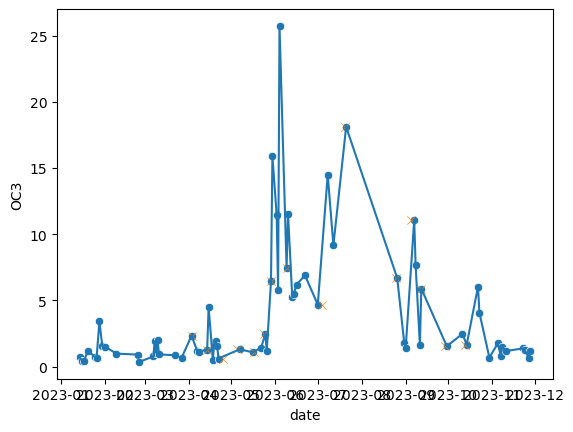

In [72]:
sns.lineplot(data=sd_chla[sd_chla.date.dt.year==2023], x='date', y='OC3')
sns.scatterplot(data=sd_chla[sd_chla.date.dt.year==2023], x='date', y='OC3')

sns.scatterplot(data=insit_melt[(insit_melt.year==2023)&(insit_melt.Algorithm=='OC3')&(insit_melt.Sensor=='SD')],
                x='Date', y='Satellite_chla', marker='x')

In [73]:
insit_melt[(insit_melt.date_diff <= '3 days')]

,Date,Chl-a,sat_date,date_diff,Algorithm,Satellite_chla,Sensor,year
0,2022-07-05,2.663,2022-07-04,1 days,OC4,6.730458,SD,2022
1,2022-07-07,2.592,2022-07-07,0 days,OC4,3.309698,SD,2022
4,2022-08-19,37.789,2022-08-20,1 days,OC4,4.268469,SD,2022
5,2022-08-25,89.650,2022-08-27,2 days,OC4,4.500733,SD,2022
6,2022-09-09,16.429,2022-09-10,1 days,OC4,3.992304,SD,2022
...,...,...,...,...,...,...,...,...
299,2023-08-25,51.580,2023-08-28,3 days,RBR3_org,0.916367,S2,2023
300,2023-09-05,28.054,2023-09-06,1 days,RBR3_org,-2.589551,S2,2023
301,2023-09-12,18.055,2023-09-12,0 days,RBR3_org,5.698419,S2,2023
302,2023-09-29,3.424,2023-09-29,0 days,RBR3_org,23.458999,S2,2023


In [74]:
print(len(insit_melt[(insit_melt.date_diff <= '3 days') & (insit_melt.Sensor=='S2')].Date.unique()))
print(len(insit_melt[(insit_melt.date_diff <= '3 days') & (insit_melt.Sensor=='SD')].Date.unique()))
print('number of chla/S2/SD matchups ^^ ')

17
21
number of chla/S2/SD matchups ^^ 


In [75]:
print(len(insit_melt[(insit_melt.date_diff == '3 days') & (insit_melt.Sensor=='SD')].Date.unique()))


2


In [76]:
insit_melt[(insit_melt.date_diff <= '3 days') & (insit_melt.Sensor=='SD')]


,Date,Chl-a,sat_date,date_diff,Algorithm,Satellite_chla,Sensor,year
0,2022-07-05,2.663,2022-07-04,1 days,OC4,6.730458,SD,2022
1,2022-07-07,2.592,2022-07-07,0 days,OC4,3.309698,SD,2022
4,2022-08-19,37.789,2022-08-20,1 days,OC4,4.268469,SD,2022
5,2022-08-25,89.650,2022-08-27,2 days,OC4,4.500733,SD,2022
6,2022-09-09,16.429,2022-09-10,1 days,OC4,3.992304,SD,2022
...,...,...,...,...,...,...,...,...
409,2023-08-25,51.580,2023-08-26,1 days,RBR3_org,-1.053782,SD,2023
410,2023-09-05,28.054,2023-09-07,2 days,RBR3_org,0.619113,SD,2023
411,2023-09-12,18.055,2023-09-12,0 days,RBR3_org,-0.374245,SD,2023
412,2023-09-29,3.424,2023-09-30,1 days,RBR3_org,5.775303,SD,2023


In [77]:
insit_melt.Algorithm = insit_melt.Algorithm.replace({'OC3':'OC3_orig',
                              'OC2':'OC2_orig',
                              'NIR_org':'NIR_orig',
                              'NDCI_org':'NDCI_orig',
                              'RBD_org':'RBD_orig',
                              'RBR3_org':'RBR3_orig'})


Algorithm = ['OC3_orig']

Sensor = ['SD']
slope: 0.15126094293486256

Algorithm = ['OC3_orig']

Sensor = ['S2']
slope: 0.20589255517746163

Algorithm = ['OC2_orig']

Sensor = ['SD']
slope: 0.24656178124508504

Algorithm = ['OC2_orig']

Sensor = ['S2']
slope: 0.2143219068211283

Algorithm = ['NIR_orig']

Sensor = ['SD']
slope: 0.0025801562023136737

Algorithm = ['NIR_orig']

Sensor = ['S2']
slope: -0.38781586077804353

Algorithm = ['OC3_tuned']

Sensor = ['SD']
slope: 0.5008099146241999

Algorithm = ['OC3_tuned']

Sensor = ['S2']
slope: 0.19105374127337363

Algorithm = ['OC2_tuned']

Sensor = ['SD']
slope: 0.4318265076202591

Algorithm = ['OC2_tuned']

Sensor = ['S2']
slope: 0.1947412811169913

Algorithm = ['NIR_tuned']

Sensor = ['SD']
slope: -9.680146504871648e-05

Algorithm = ['NIR_tuned']

Sensor = ['S2']
slope: 0.09446006420133785

Algorithm = ['NDCI_orig']

Sensor = ['SD']
slope: 0.016137484267274044

Algorithm = ['NDCI_orig']

Sensor = ['S2']
slope: -0.5723365916324898

Algorith

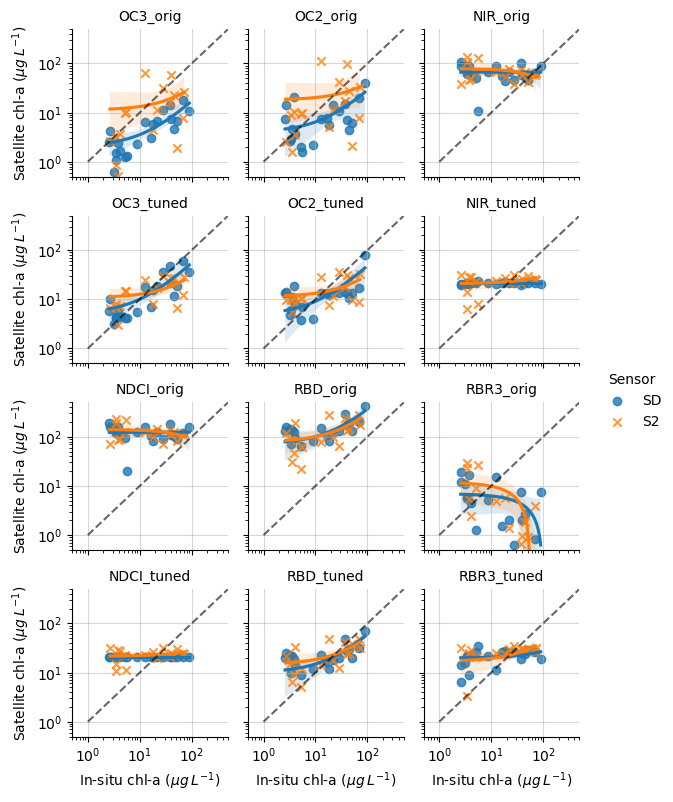

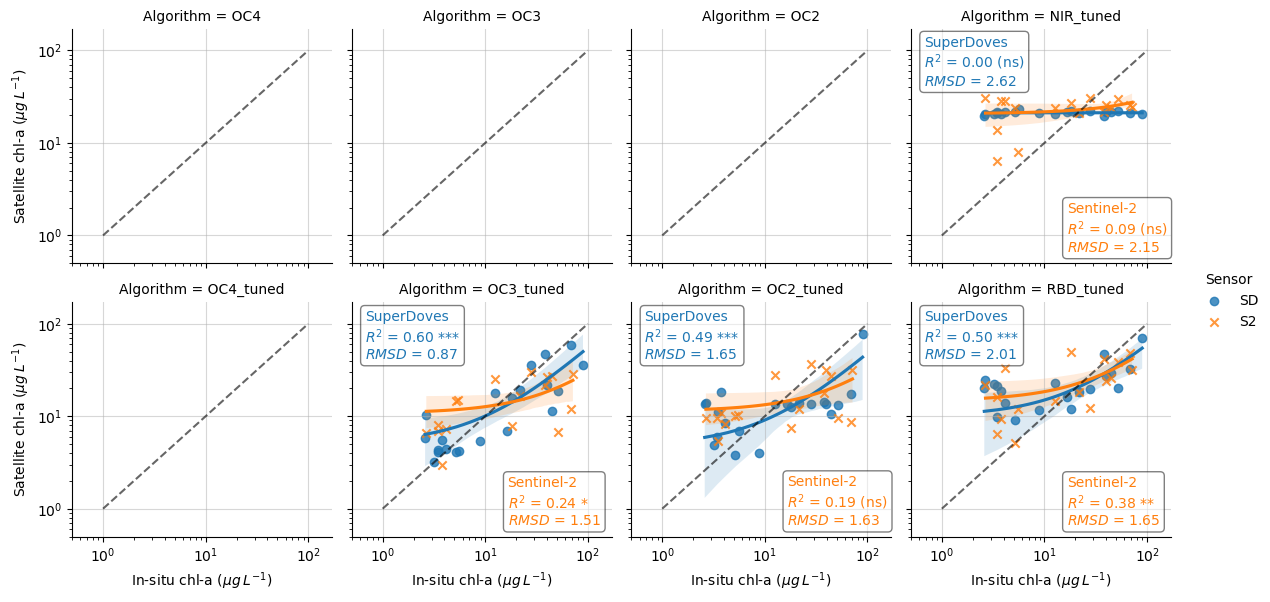

In [78]:
def annotate(data, x='Chl-a', y='sdfkjdf', order=1, plot=True, lims=None, **kws):
    res = sp.stats.linregress(data.dropna()[x]**order, data.dropna()[y])
    mae = MAE(data.dropna()[x], data.dropna()[y])
    mape = MAPE(data.dropna()[x], data.dropna()[y])
    rmsd = RMSD(data.dropna()[x], data.dropna()[y])
    bias = SSPB(data.dropna()[x], data.dropna()[y])
    mad = MAD(data.dropna()[x], data.dropna()[y])
    mapd = MAPD(data.dropna()[x], data.dropna()[y])
    
    psig = p_sig(res.pvalue)
    slope = res.slope
    
    print('\nAlgorithm = ' + str(data.Algorithm.unique()))
    print('\nSensor = ' + str(data.Sensor.unique()))

    print('slope: ' + str(slope))
#     print('MAPD: ' + str(mapd))
#     print('bias: ' + str(bias))
#     print('R2: ' + str(res.rvalue**2))
#     print('p-val: ' + str(res.pvalue))
    
#     print(str(rmsd))
#     print(str(mapd))
#     print(str(bias))
#     if np.isnan(bias):
#         print(list(data.dropna()[x]))
#         print(list(data.dropna()[y]))
#     print(str(res.rvalue**2))
#     print(str(res.pvalue))
    
    ax = plt.gca()
#     if data.Sensor.values[0] == 'SD':
#         textstr = '\n'.join((
#                              r'SuperDoves',
#                              r'$R^2$ = {:.2f} {}'.format(res.rvalue**2,
#                                                          psig),
#         #                     r'$RMSD$ = {:.2f}'.format(rmsd, )
#         ))
#         ax.text(0.05, 0.76, textstr,
#             transform=ax.transAxes, bbox=dict(boxstyle='round',
#                                               facecolor='white',
#                                               alpha=0.5),
#                 color=sns.color_palette()[0])
#     if data.Sensor.values[0] == 'S2':
#         textstr = '\n'.join((
#                              r'Sentinel-2',
#                              r'$R^2$ = {:.2f} {}'.format(res.rvalue**2,
#                                                          psig),
#                              #r'$RMSD$ = {:.2f}'.format(rmsd, )
#                                                                 ))
#         ax.text(0.6, 0.05, textstr,
#             transform=ax.transAxes, bbox=dict(boxstyle='round',
#                                               facecolor='white',
#                                               alpha=0.5),
#                 color=sns.color_palette()[1])

    if plot:
        ax.plot([0.1, 100], [0.1, 100], 'k--', alpha=0.6)

g = sns.lmplot(data=insit_melt[(insit_melt.date_diff <= '3 days')& ~not_tuned],
               x='Chl-a', y='Satellite_chla', col='Algorithm', hue='Sensor',
               col_wrap=3, markers=['o', 'x'],
               col_order=['OC3_orig', 'OC2_orig', 'NIR_orig',
                          'OC3_tuned', 'OC2_tuned',  'NIR_tuned',
                           'NDCI_orig', 'RBD_orig', 'RBR3_orig',
                          'NDCI_tuned','RBD_tuned',  'RBR3_tuned'],
               facet_kws={'sharey':True, 'sharex':True}, height=2.)

g.set_titles("{col_name}")

g.map_dataframe(annotate, y='Satellite_chla', plot=False)# lims=[0.1, 100])

for ax in g.axes:
    ax.set_xlim(.5e0, 5e2)
    ax.set_ylim(.5e0, 5e2)
    ax.plot([1e0, 500], [1e0, 500], 'k--', alpha=0.6)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.grid(alpha=0.5)
    ax.set_xlabel('In-situ chl-a ($\mu g \: L^{-1}$)')
    ax.set_ylabel('Satellite chl-a ($\mu g \: L^{-1}$)')
    
plt.savefig('figures_for_paper/alg_comparison.svg', dpi=300)

    
plt.show()

def annotate(data, x='Chl-a', y='sdfkjdf', order=1, plot=True, lims=None, **kws):
    res = sp.stats.linregress(data.dropna()[x]**order, data.dropna()[y])
    mae = MAE(data.dropna()[x], data.dropna()[y])
    mape = MAPE(data.dropna()[x], data.dropna()[y])
    rmsd = RMSD(data.dropna()[x], data.dropna()[y])
    bias = SSPB(data.dropna()[x], data.dropna()[y])
    mad = MAD(data.dropna()[x], data.dropna()[y])
    mapd = MAPD(data.dropna()[x], data.dropna()[y])
    
    psig = p_sig(res.pvalue)
    
    ax = plt.gca()
    if data.Sensor.values[0] == 'SD':
        textstr = '\n'.join((
                             r'SuperDoves',
                             r'$R^2$ = {:.2f} {}'.format(res.rvalue**2,
                                                         psig),
                             r'$RMSD$ = {:.2f}'.format(rmsd, )))
        ax.text(0.05, 0.76, textstr,
            transform=ax.transAxes, bbox=dict(boxstyle='round',
                                              facecolor='white',
                                              alpha=0.5),
                color=sns.color_palette()[0])
    if data.Sensor.values[0] == 'S2':
        textstr = '\n'.join((
                             r'Sentinel-2',
                             r'$R^2$ = {:.2f} {}'.format(res.rvalue**2,
                                                         psig),
                             r'$RMSD$ = {:.2f}'.format(rmsd, )))
        ax.text(0.6, 0.05, textstr,
            transform=ax.transAxes, bbox=dict(boxstyle='round',
                                              facecolor='white',
                                              alpha=0.5),
                color=sns.color_palette()[1])

    if plot:
        ax.plot([0.1, 100], [0.1, 100], 'k--', alpha=0.6)

g = sns.lmplot(data=insit_melt[(insit_melt.date_diff <= '3 days')& ~not_tuned],
               x='Chl-a', y='Satellite_chla', col='Algorithm', hue='Sensor',
               col_wrap=4, markers=['o', 'x'], col_order=['OC4', 'OC3', 'OC2',
                                                          'NIR_tuned',
                                                          'OC4_tuned', 'OC3_tuned',
                                                          'OC2_tuned','RBD_tuned'
                                                          ],
               facet_kws={'sharey':True, 'sharex':True}, height=3.)

g.map_dataframe(annotate, y='Satellite_chla', plot=False)# lims=[0.1, 100])

for ax in g.axes:
    ax.set_xlim(.5e0, 1.7e2)
    ax.set_ylim(.5e0, 1.7e2)
    ax.plot([1e0, 100], [1e0, 100], 'k--', alpha=0.6)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.grid(alpha=0.5)
    ax.set_xlabel('In-situ chl-a ($\mu g \: L^{-1}$)')
    ax.set_ylabel('Satellite chl-a ($\mu g \: L^{-1}$)')
    
plt.savefig('figs_for_presentation/alg_validation.svg', dpi=300)

    
plt.show()

In [79]:
res

NameError: name 'res' is not defined

In [ ]:
x = np.array([2.663, 2.592, 37.789, 89.65, 16.429, 21.707, 8.825, 5.158, 3.189, 5.59, 3.483,
     3.776, 12.53, 39.744, 44.595, 68.487, 51.58, 28.054, 18.055, 3.424, 4.118])
y = np.array([159.13257622923703, 131.99088834989817, 294.9978086382151, 430.5066045589745,
     109.06063111331314, 121.09814380593598, 81.43292310363613, 65.94360585622489,
     143.54730457365514, -132.005822301656, 138.56552880555392, 122.68235235307365,
     148.39999596886338, 173.9232424490154, 188.3922958077863, 204.32564962022008,
     132.4338990852237, 130.09774292185904, 83.56709034945816,
     70.66139823822304, 95.21277783736586])

SSPB(np.array(x), np.array(y))


med = np.log(y / x)
#     return np.sign(med) * (np.exp(np.abs(med)) - 1) * 100

In [80]:
y[9]/x[9]

NameError: name 'y' is not defined

In [71]:
SD_best = (insit_melt.Algorithm=='RBD_tuned') & (insit_melt.Sensor=='SD')
S2_best = (insit_melt.Algorithm=='RBD_tuned') & (insit_melt.Sensor=='S2')

In [62]:
m_years = mdates.YearLocator()   # every year
m_months = mdates.MonthLocator()  # every month
monthsFmt = mdates.DateFormatter('%b \'%y')

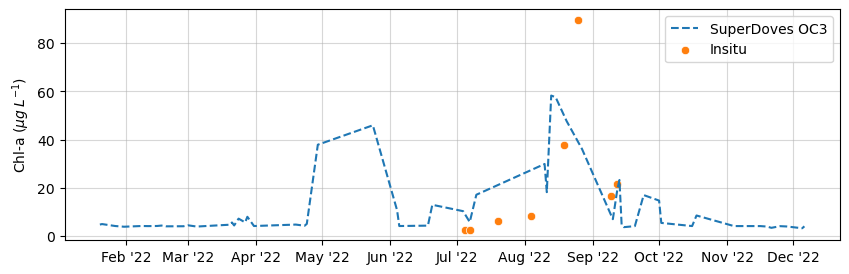

In [73]:
fig, ax = plt.subplots(1, 1, figsize=(10,3))
sns.lineplot(data=sd_chla[sd_chla.date.dt.year==2022],
                x='date', y='OC3_tuned', label='SuperDoves OC3',ax=ax, errorbar=None,
             color=sns.color_palette()[0], linestyle='--',
               )

# sns.lineplot(data=s2_chla[(s2_chla.date.dt.year==2023)&(~s2_chla.date.dt.month.isin([1, 2, 3, 11, 12]))],
#                 x='date', y='OC3_tuned', label='Sentinel-2 OC3', ax=ax, errorbar=None,
#               color=sns.color_palette()[2]
#                )

# sns.lineplot(data=sd_chla[sd_chla.date.dt.year==2023],
#                 x='date', y='OC4_tuned', label='SD OC3', ax=ax,errorbar=None,
#                )




sns.scatterplot(data=insit_melt[(insit_melt.Algorithm=='OC4_tuned')&(insit_melt.year==2022)&(insit_melt.Sensor=='SD')],
            x='Date', y='Chl-a', label='Insitu', ax=ax, #marker='o', color='g',
                color=sns.color_palette()[1]
            )
# ax.set_ylim(1, 100)
ax.set_ylabel('Chl-a ($\mu g \: L^{-1}$)')
ax.set_xlabel('')
ax.xaxis.set_major_locator(m_months)
ax.xaxis.set_major_formatter(monthsFmt)
ax.grid(alpha=0.5)

ax.legend()
# fig.autofmt_xdate()



In [74]:
sd_chla.columns

Index(['date', 'Date', 'Rrs_444', 'Rrs_492', 'Rrs_533', 'Rrs_566', 'Rrs_612',
       'Rrs_666', 'Rrs_707', 'Rrs_866', 'NIR', 'NDCI', 'OC4_X', 'OC4_mod_X',
       'OC3_X', 'OC2_X', 'OC4', 'OC3', 'OC2', 'RBD', 'RBR3', 'OC2_tuned',
       'OC3_tuned', 'OC4_tuned', 'NIR_tuned', 'NDCI_tuned', 'RBD_tuned',
       'RBR3_tuned'],
      dtype='object')

Axes(0.125,0.53;0.352273x0.35)
['SuperDoves OC3', 'SuperDoves OC3', 'Insitu']
Axes(0.547727,0.53;0.352273x0.35)
['SuperDoves OC3', 'SuperDoves OC3', 'Insitu']
Axes(0.125,0.11;0.352273x0.35)
['Sentinel-2 RBD', 'Sentinel-2 RBD', 'Insitu']
Axes(0.547727,0.11;0.352273x0.35)
['Sentinel-2 RBD', 'Sentinel-2 RBD', 'Insitu']


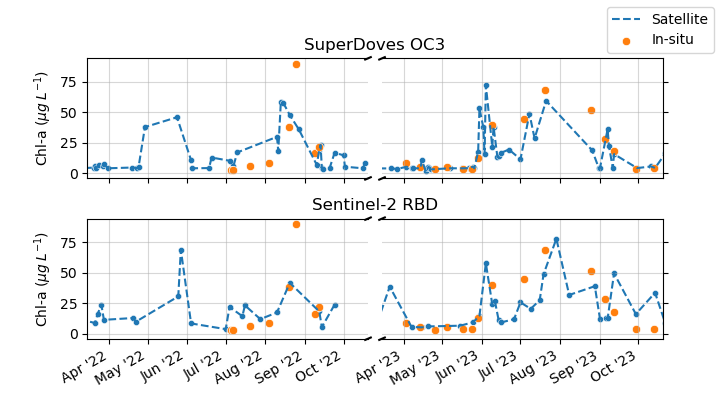

In [109]:
fig, axs = plt.subplots(2, 2, figsize=(7, 4), sharey=True)

algs = ['OC3_tuned', 'RBD_tuned']
labs = ['SuperDoves OC3', 'Sentinel-2 RBD']
dfs = [sd_chla, s2_chla]

for axi, alg, df, lab in zip([0, 1], algs, dfs, labs):
    
    for yr, axj in zip([2022, 2023], [0, 1]):
        sns.lineplot(data=df[df.date.dt.year.isin([yr])],
                        x='date', y=alg, label=lab, ax=axs[axi, axj], errorbar=None,
                     color=sns.color_palette()[0], linestyle='--',
                     legend=False
                       )
        sns.scatterplot(data=df[df.date.dt.year.isin([yr])],
                        x='date', y=alg, label=lab, ax=axs[axi, axj], 
                     color=sns.color_palette()[0], s=20,
                     legend=False
                       )

        axs[axi, 0].set_title('                                                        ' + lab)
        



# hide the spines between ax and ax2



for ax in axs.flatten():
    sns.scatterplot(data=insit_melt[(insit_melt.Algorithm=='OC4_tuned')&(insit_melt.year.isin([2022,2023]))],
                x='Date', y='Chl-a', label='Insitu', ax=ax, #marker='o', color='g',
                    color=sns.color_palette()[1], legend=False,
                )
    

axs[0, 0].set_xlim(pd.to_datetime('2022-03-15'), pd.to_datetime('2022-10-20'))
axs[1, 0].set_xlim(pd.to_datetime('2022-03-15'), pd.to_datetime('2022-10-20'))
axs[1, 1].set_xlim(pd.to_datetime('2023-03-15'), pd.to_datetime('2023-10-20'))
axs[0, 1].set_xlim(pd.to_datetime('2023-03-15'), pd.to_datetime('2023-10-20'))
    
for ax, ax2 in [(axs[0, 0], axs[0, 1]), (axs[1, 0], axs[1, 1])]:
    ax.spines['right'].set_visible(False)
    ax2.spines['left'].set_visible(False)
    ax.yaxis.tick_left()
#     ax.tick_params(labelright='off')
    ax2.yaxis.tick_right()
    
    d = .01  # how big to make the diagonal lines in axes coordinates
    # arguments to pass plot, just so we don't keep repeating them
    kwargs = dict(transform=ax.transAxes, color='k', clip_on=False)
    ax.plot((1-d, 1+d), (-d, +d), **kwargs)
    ax.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

    kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
    ax2.plot((-d, +d), (1-d, 1+d), **kwargs)
    ax2.plot((-d, +d), (-d, +d), **kwargs)
    
for ax in axs.flatten():
#     ax.set_ylim(0, 120)
    print(ax)
    ax.set_ylabel('Chl-a ($\mu g \: L^{-1}$)')
    ax.set_xlabel('')
#     ax.xaxis.set_major_locator(m_months)
    ax.xaxis.set_major_formatter(monthsFmt)
#     ax.xaxis.set_major_locator(m_months)
    ax.grid(alpha=0.5)
    ax.legend()
    h, l = ax.get_legend_handles_labels()
    print(l)
    ax.get_legend().remove()


    
fig.legend(handles=[item for item in [h[0], h[2]]], labels= ['Satellite',
                                                      'In-situ'])
fig.autofmt_xdate()
plt.tight_layout(rect=(0, 0, 0.95, 0.95))

fig.subplots_adjust(wspace=0.05)

plt.savefig('figures_for_paper/SD_S2_insitu_chla_timeseries.svg', dpi=300)

plt.show()



In [125]:
insit_melt.Date.unique()

<DatetimeArray>
['2022-07-05 00:00:00', '2022-07-07 00:00:00', '2022-07-20 00:00:00',
 '2022-08-04 00:00:00', '2022-08-19 00:00:00', '2022-08-25 00:00:00',
 '2022-09-09 00:00:00', '2022-09-12 00:00:00', '2023-04-03 00:00:00',
 '2023-04-14 00:00:00', '2023-04-25 00:00:00', '2023-05-05 00:00:00',
 '2023-05-17 00:00:00', '2023-05-24 00:00:00', '2023-05-29 00:00:00',
 '2023-06-09 00:00:00', '2023-07-04 00:00:00', '2023-07-20 00:00:00',
 '2023-08-25 00:00:00', '2023-09-05 00:00:00', '2023-09-12 00:00:00',
 '2023-09-29 00:00:00', '2023-10-13 00:00:00', '2022-07-27 00:00:00',
 '2023-08-08 00:00:00']
Length: 25, dtype: datetime64[ns]

## Get data from the entire SD timeseries


In [341]:
sd_chla.date.unique()

<DatetimeArray>
['2020-04-07 00:00:00', '2020-09-18 00:00:00', '2020-09-26 00:00:00',
 '2020-11-19 00:00:00', '2020-11-25 00:00:00', '2020-12-03 00:00:00',
 '2021-01-06 00:00:00', '2021-01-12 00:00:00', '2021-01-22 00:00:00',
 '2021-01-25 00:00:00',
 ...
 '2024-02-07 00:00:00', '2024-02-22 00:00:00', '2024-02-24 00:00:00',
 '2024-02-26 00:00:00', '2024-03-01 00:00:00', '2024-03-04 00:00:00',
 '2024-03-16 00:00:00', '2024-03-22 00:00:00', '2024-03-31 00:00:00',
 '2024-04-08 00:00:00']
Length: 189, dtype: datetime64[ns]

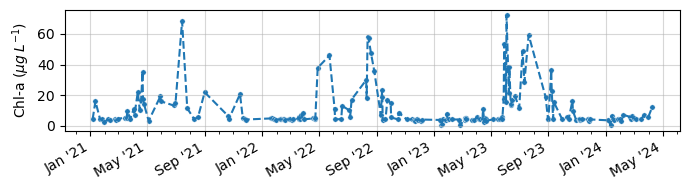

In [65]:
fig, ax = plt.subplots(1, 1, figsize=(7, 2.))
sns.lineplot(data=sd_chla[sd_chla.date.dt.year!=2020],
             x='date', y='OC3_tuned', ax=ax,
                     color=sns.color_palette()[0], linestyle='--',
                     legend=False
                       )
sns.scatterplot(data=sd_chla[sd_chla.date.dt.year!=2020],
             x='date', y='OC3_tuned', ax=ax,
                     color=sns.color_palette()[0],
                s=15,
                       )
ax.grid(alpha=0.5)
ax.xaxis.set_major_formatter(monthsFmt)
ax.xaxis.set_minor_locator(m_months)
fig.autofmt_xdate()
ax.set_ylabel('Chl-a ($\mu g \: L^{-1}$)')
ax.set_xlabel('')

plt.tight_layout()
plt.savefig('figures_for_paper/SD_chla_timeseries.svg', dpi=300)


plt.show()


Text(0.5, 0, '')

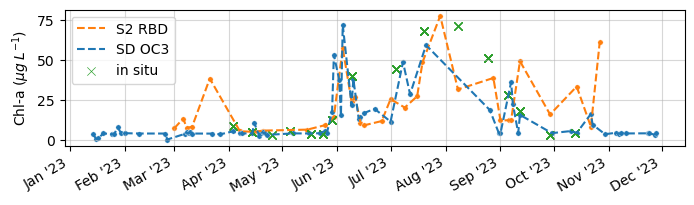

In [97]:
fig, ax = plt.subplots(1, 1, figsize=(8, 2.))

sns.lineplot(data=s2_chla[s2_chla.date.dt.year==2023],
             x='date', y='RBD_tuned', ax=ax,
                     color=sns.color_palette()[1], linestyle='--',
                     legend=False, label='S2 RBD'
                       )
sns.scatterplot(data=s2_chla[s2_chla.date.dt.year==2023],
             x='date', y='RBD_tuned', ax=ax,
                     color=sns.color_palette()[1],
                s=15,
                       )
ax.grid(alpha=0.5)
ax.xaxis.set_major_formatter(monthsFmt)
ax.xaxis.set_minor_locator(m_months)
fig.autofmt_xdate()
ax.set_ylabel('Chl-a ($\mu g \: L^{-1}$)')
ax.set_xlabel('')

sns.lineplot(data=sd_chla[sd_chla.date.dt.year==2023],
             x='date', y='OC3_tuned', ax=ax,
                     color=sns.color_palette()[0], linestyle='--',
                     legend=False, label='SD OC3'
                       )
sns.scatterplot(data=sd_chla[sd_chla.date.dt.year==2023],
             x='date', y='OC3_tuned', ax=ax,
                     color=sns.color_palette()[0],
                s=15,
                       )

sns.scatterplot(data=insit_melt[insit_melt.Date.dt.year==2023], y='Chl-a', x='Date',
                marker='x', color=sns.color_palette()[2], label='in situ')

ax.grid(alpha=0.5)
ax.xaxis.set_major_formatter(monthsFmt)
ax.xaxis.set_minor_locator(m_months)
fig.autofmt_xdate()
ax.set_ylabel('Chl-a ($\mu g \: L^{-1}$)')
ax.set_xlabel('')

Text(0.5, 0, '')

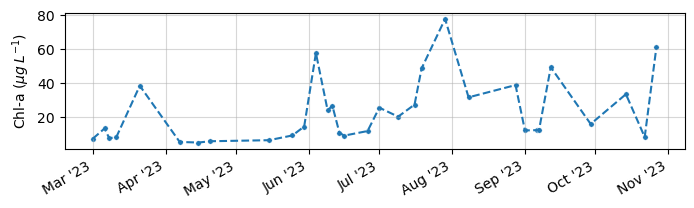

In [84]:
fig, ax = plt.subplots(1, 1, figsize=(8, 2.))
sns.lineplot(data=s2_chla[s2_chla.date.dt.year==2023],
             x='date', y='RBD_tuned', ax=ax,
                     color=sns.color_palette()[0], linestyle='--',
                     legend=False
                       )
sns.scatterplot(data=s2_chla[s2_chla.date.dt.year==2023],
             x='date', y='RBD_tuned', ax=ax,
                     color=sns.color_palette()[0],
                s=15,
                       )
ax.grid(alpha=0.5)
ax.xaxis.set_major_formatter(monthsFmt)
ax.xaxis.set_minor_locator(m_months)
fig.autofmt_xdate()
ax.set_ylabel('Chl-a ($\mu g \: L^{-1}$)')
ax.set_xlabel('')

In [77]:
sd_chla.columns

Index(['date', 'Date', 'Rrs_444', 'Rrs_492', 'Rrs_533', 'Rrs_566', 'Rrs_612',
       'Rrs_666', 'Rrs_707', 'Rrs_866', 'NIR', 'NDCI', 'OC4_X', 'OC4_mod_X',
       'OC3_X', 'OC2_X', 'OC4', 'OC3', 'OC2', 'RBD', 'RBR3', 'OC2_tuned',
       'OC3_tuned', 'OC4_tuned', 'NIR_tuned', 'NDCI_tuned', 'RBD_tuned',
       'RBR3_tuned'],
      dtype='object')

# Now just need some nice maps

- could try generating maps for all the data
    - although my current method doesn't automate the QGIS part...
    - so generate
- need to compare S2 and acolite 
    - ultimately I probably only want maybe 5 dates (eg. for a 2x5 plot comparison s2 and acolite?)